In [ ]:
TARGET_PROTEIN = "IRAK4"

In [134]:
from pathlib import Path

def create_protein_project(protein_name):
    """
    Create a directory structure for a protein project.

    Structure:
    protein_name/
    ├── txts/
    ├── csvs/
    ├── generated/
    ├── sections/
    └── images/
    └── scaffolds/

    """

    base_path = Path(protein_name)
    subfolders = [
        "txts",
        "csvs",
        "generated",
        "sections",
        "images",
        "scaffolds"
    ]
    # Create main folder
    base_path.mkdir(exist_ok=True)
    # Create subfolders
    for folder in subfolders:
        (base_path / folder).mkdir(exist_ok=True)

    print(f"Created project structure for: {protein_name}")

create_protein_project(TARGET_PROTEIN)

Created project structure for: GLP1R


**TARGET PROFILE**

In [135]:
from src.target_profile import fetch_uniprot, fetch_open_targets, fetch_kegg_pathways, synthesise_target_profile


def get_target_profile(protein_name: str) -> str:
    print(f"\nFetching target profile for: {protein_name}")

    print("  [1/4] UniProt...")
    uniprot = fetch_uniprot(protein_name)

    # Use symbol from UniProt accession for downstream queries if available
    gene_symbol = protein_name  # fallback

    print("  [2/4] Open Targets...")
    open_targets = fetch_open_targets(protein_name)
    if open_targets.get("symbol"):
        gene_symbol = open_targets["symbol"]

    print(f"  [3/4] KEGG (gene: {gene_symbol})...")
    kegg_pathways = fetch_kegg_pathways(gene_symbol)

    print("  [4/4] LLM Synthesis...")
    narrative = synthesise_target_profile(protein_name, uniprot, open_targets, kegg_pathways)

    return narrative

# ── Input ───────────────────────────────────────────────────────


profile = get_target_profile(TARGET_PROTEIN)
with open(f"{TARGET_PROTEIN}/txts/{TARGET_PROTEIN}_target_profile.txt", "w") as f:
    f.write(profile)


Fetching target profile for: GLP1R
  [1/4] UniProt...
{'accession': 'P43220', 'comments': {'function': 'G-protein coupled receptor for glucagon-like peptide 1 (GLP-1) (PubMed:19861722, PubMed:26308095, PubMed:27196125, PubMed:28514449, PubMed:7517895, PubMed:8216285, PubMed:8405712). Ligand binding triggers activation of a signaling cascade that leads to the activation of adenylyl cyclase and increased intracellular cAMP levels (PubMed:19861722, PubMed:26308095, PubMed:27196125, PubMed:28514449, PubMed:7517895, PubMed:8216285, PubMed:8405712). Plays a role in regulating insulin secretion in response to GLP-1 (By similarity)', 'subunit': 'May form homodimers and heterodimers with GIPR'}}
  [2/4] Open Targets...
    [Open Targets] GraphQL errors: [{'message': "Cannot query field 'knownDrugs' on type 'Target'. (line 20, column 9):\n        knownDrugs(size: 10) {\n        ^", 'locations': [{'line': 20, 'column': 9}]}]
  [3/4] KEGG (gene: GLP1R)...
  [4/4] LLM Synthesis...


**JSON: TARGET PROFILE**

In [136]:
# ── JSON: Target Profile ─────────────────────────────────────────────────────
import json, os, re

_tp_path = f"{TARGET_PROTEIN}/txts/{TARGET_PROTEIN}_target_profile.txt"
with open(_tp_path, encoding="utf-8") as _f:
    _profile_text = _f.read()

def _parse_profile_sections(text):
    parts = re.split(r'\*\*(.+?)\*\*', text)
    subs = []
    it = iter(parts)
    preamble = next(it, "").strip()
    if preamble:
        subs.append({"heading":"","type":"text","content":preamble})
    for heading, body in zip(it, it):
        heading = heading.strip(); body = body.strip()
        if heading:
            subs.append({"heading":"","type":"profile_heading","content":heading})
        if body:
            subs.append({"heading":"","type":"text","content":body})
    subs.append({"heading":"","type":"source_note",
                 "content":"Sources: UniProt · Open Targets · KEGG"})
    return subs

_tp_section = {
    "title": "Target Profile",
    "sections": _parse_profile_sections(_profile_text)
}

os.makedirs(f"{TARGET_PROTEIN}/sections", exist_ok=True)
with open(f"{TARGET_PROTEIN}/sections/00_target_profile.json","w",encoding="utf-8") as _f:
    json.dump(_tp_section, _f, indent=2, ensure_ascii=False)
print(f"✓ Target profile JSON saved")


✓ Target profile JSON saved


**CLINICAL TRIAL AND PATENT DATA EXTRACTION**

- Selective Molecule Study

In [138]:
import src.chembl_approved_clin as clin
import importlib
importlib.reload(clin)
from src.chembl_approved_clin import (get_uniprot_ids, get_chembl_target, get_clinical_molecules, 
                                      run_selectivity_pipeline, build_enriched_clinical_df )  


uniprot_info = get_uniprot_ids(TARGET_PROTEIN)

human_uniprot = (
    uniprot_info["human"]["uniprot_id"]
    if uniprot_info["human"]
    else None
)

mouse_uniprot = (
    uniprot_info["mouse"]["uniprot_id"]
    if uniprot_info["mouse"]
    else None
)

print("\nHuman UniProt :", human_uniprot)
print("Mouse UniProt :", mouse_uniprot)

chembl_target = get_chembl_target(human_uniprot)
target_chembl_id = chembl_target["target_chembl_id"]
print(f"Target ChEMBL ID: {target_chembl_id}")

print(f"Fetching clinical molecules for {target_chembl_id}...")
clinical_df = get_clinical_molecules(target_chembl_id)

print(clinical_df)
# replaces the old enrich_with_pdb call + save_ids_and_molecules call
df_all, _ = run_selectivity_pipeline(f"{TARGET_PROTEIN}", selectivity_delta_threshold=1.0)

clinical_df, pdb_detail_df, top5_target_pdbs, offtarget_map = build_enriched_clinical_df(
    clinical_df=clinical_df,           # from get_clinical_molecules()
    df_all=df_all,
    target_chembl_id=target_chembl_id,
    human_uniprot=human_uniprot,
    mouse_uniprot=mouse_uniprot,
    chembl_target=chembl_target,
    selectivity_delta_threshold= 1.0,       # tighter threshold for selectivity flagging in the clinical set (can adjust as needed
)

df_selective = clinical_df[clinical_df["is_selective"] == True]


Searching HUMAN UniProt for: GLP1R
   ✔ Matched with query: gene_exact:"GLP1R" AND organism_id:9606 AND reviewed:true

✅ HUMAN MATCH
   Protein : Glucagon-like peptide 1 receptor
   Gene    : GLP1R
   UniProt : P43220

Searching MOUSE using human gene symbol: GLP1R

✅ MOUSE MATCH
   Protein : Glucagon-like peptide 1 receptor
   Gene    : Glp1r
   UniProt : O35659

Human UniProt : P43220
Mouse UniProt : O35659
✅ ChEMBL Target(s) found for P43220:
   CHEMBL1784 — Glucagon-like peptide 1 receptor (Homo sapiens)

➡️  Using: CHEMBL1784 — Glucagon-like peptide 1 receptor
Target ChEMBL ID: CHEMBL1784
Fetching clinical molecules for CHEMBL1784...
   molecule_chembl_id       pref_name  \
0        CHEMBL414357       EXENATIDE   
1       CHEMBL2107841     ALBIGLUTIDE   
2       CHEMBL2107860    TASPOGLUTIDE   
3       CHEMBL2108027     DULAGLUTIDE   
4       CHEMBL2108336    LIXISENATIDE   
5       CHEMBL2108724     SEMAGLUTIDE   
6       CHEMBL3990012  PEGAPAMODUTIDE   
7       CHEMBL4084119   

Clinical Trial And Patent Data Extraction

In [139]:
import src.clin_trial_patent_data as ctpd
importlib.reload(ctpd)
from src.clin_trial_patent_data import generate_report

# ═══════════════════════════════════════════════════════════════════════════════
# RUN
# ═══════════════════════════════════════════════════════════════════════════════
result = generate_report(TARGET_PROTEIN, df_selective=df_selective)
_ct_data = result["_ct_data"] 
print(f"\nDone. → {result}")


  Target Landscape Report
  Protein: GLP1R
  Fetching studies from ClinicalTrials.gov…
  [GLP1R] fetching… 556 studies
  [LIRAGLUTIDE] fetching… 539 studies
  [SEMAGLUTIDE] fetching… 713 studies
  [ORFORGLIPRON] fetching… 46 studies
  [DANUGLIPRON] fetching… 20 studies
  [GLP-1] fetching… 4038 studies
  [LOTIGLIPRON] fetching… 2 studies
  Total unique studies after deduplication: 4534
  Processing data…
  Unique intervention names before LLM: 2051
  LLM filtering in batches of 50…
    batch 1: 50 in → 20 kept
    batch 2: 50 in → 11 kept
    batch 3: 50 in → 17 kept
    batch 4: 50 in → 11 kept
    batch 5: 50 in → 7 kept
    batch 6: 50 in → 7 kept
    batch 7: 50 in → 14 kept
    batch 8: 50 in → 11 kept
    batch 9: 50 in → 20 kept
    batch 10: 50 in → 35 kept
    batch 11: 50 in → 27 kept
    batch 12: 50 in → 7 kept
    batch 13: 50 in → 22 kept
    batch 14: 50 in → 5 kept
    batch 15: 50 in → 18 kept
    batch 16: 50 in → 29 kept
    batch 17: 50 in → 3 kept
    batch 18: 50 

**JSON: CLINICAL TRIAL DATA**

In [140]:
# ── JSON: Clinical Trials sections 01–07 ────────────────────────────────────
from src.clin_trial_patent_data import fetch_all_studies, process_studies, parse_date

import json
import os
from datetime import datetime

try:
    _ct_data

except NameError:
    _ct_studies = fetch_all_studies(TARGET_PROTEIN)
    _ct_data = process_studies(_ct_studies, TARGET_PROTEIN)


def _w(path, obj):
    """Write JSON helper."""
    with open(path, "w", encoding="utf-8") as _f:
        json.dump(obj, _f, indent=2, ensure_ascii=False)
    print(f"    {path}")


# ---------------------------------------------------------------------------
# Image paths
# ---------------------------------------------------------------------------
TREND_CHART   = f"{TARGET_PROTEIN}/images/chart_trend.png"
SPONSOR_CHART = f"{TARGET_PROTEIN}/images/chart_sponsors.png"
COLLAB_CHART  = f"{TARGET_PROTEIN}/images/chart_collabs.png"


# ---------------------------------------------------------------------------
# 01 Overview
# ---------------------------------------------------------------------------
_w(f"{TARGET_PROTEIN}/sections/01_overview.json", {
    "title": "Overview & Trial Trend",
    "sections": [
        {
            "heading": "",
            "type": "stat_tiles",
            "content": [
                {"label": "Total Studies",    "value": str(_ct_data["total"])},
                {"label": "Completed",        "value": str(_ct_data["completed"])},
                {"label": "Ongoing / Active", "value": str(_ct_data["ongoing"])},
                {"label": "Withdrawn",        "value": str(_ct_data["withdrawn_count"])},
                {"label": "Other",            "value": str(_ct_data["other"])},
            ]
        }
    ]
})


# ---------------------------------------------------------------------------
# 02 Conditions
# ---------------------------------------------------------------------------
_cond = [["Condition", "Studies"]] + [
    [c, str(n)]
    for c, n in _ct_data["conditions"].most_common(15)
]

_w(f"{TARGET_PROTEIN}/sections/02_conditions.json", {
    "title": "Associated Conditions / Diseases",
    "sections": [
        {
            "heading": "",
            "type": "table",
            "content": _cond
        }
    ]
})


# ---------------------------------------------------------------------------
# 03 Interventions  (replaces old 03 Small Molecules + 04 Drug Codenames)
#
# _ct_data["interventions_all"] is a list of (name, nct_ids_str) tuples,
# sorted alphabetically by name, produced by process_studies().
# ---------------------------------------------------------------------------
_interventions = _ct_data.get("interventions_all", [])

_w(f"{TARGET_PROTEIN}/sections/03_interventions.json", {
    "title": "All Interventions (unique entries from trial data)",
    "sections": (
        [
            {
                "heading": "",
                "type": "text",
                "content": "No intervention data found."
            }
        ]
        if not _interventions else
        [
            {
                "heading": "",
                "type": "text",
                "content": (
                    "All unique intervention names recorded across clinical trials "
                    "for this target, with the NCT ID(s) of the studies they appear in."
                )
            },
            {
                "heading": "",
                "type": "table",
                "content": (
                    [["Intervention Name", "NCT ID(s)"]] +
                    [[name, nct_ids_str] for name, nct_ids_str in _interventions]
                )
            }
        ]
    )
})


# ---------------------------------------------------------------------------
# 04 Combination Therapies  (was 05)
# Derived from studies where 2+ interventions survived the LLM filter.
# Each row = one study: all its surviving intervention names + its NCT ID.
# ---------------------------------------------------------------------------
_combo_rows = _ct_data.get("combo_rows", [])

_w(f"{TARGET_PROTEIN}/sections/04_combo.json", {
    "title": "Combination Therapies / Products",
    "sections": (
        [
            {
                "heading": "",
                "type": "text",
                "content": "No combination therapies identified."
            }
        ]
        if not _combo_rows else
        [
            {
                "heading": "",
                "type": "text",
                "content": (
                    "Studies where two or more interventions passed the drug-name filter. "
                    "Each row represents one study."
                )
            },
            {
                "heading": "",
                "type": "table",
                "content": (
                    [["Interventions", "NCT ID"]] +
                    [[interventions_str, nct_id] for interventions_str, nct_id in _combo_rows]
                )
            }
        ]
    )
})


# ---------------------------------------------------------------------------
# 05 Sponsors  (was 06)
# ---------------------------------------------------------------------------
def _sp_subs(entities, entity_studies):
    subs = [{
        "heading": "",
        "type": "text",
        "content": (
            "Bars = annual study count · "
            "Line = cumulative total · "
            "Last 10 years."
        )
    }]

    for _e in entities:
        _sl2 = sorted(
            entity_studies.get(_e, []),
            key=lambda x: (parse_date(x.get("start", "")) or datetime.min),
            reverse=True
        )[:8]

        subs.append({"heading": _e, "type": "text", "content": ""})

        if _sl2:
            _r2 = [["Study Title", "NCT ID", "Phase", "Status", "Start", "End"]]
            for _s2 in _sl2:
                _t2 = _s2["title"]
                _r2.append([
                    (_t2[:75] + ("…" if len(_t2) > 75 else "")),
                    _s2["nct_id"],
                    _s2["phase"],
                    _s2["status"],
                    _s2.get("start", "—") or "—",
                    _s2.get("end", "—") or "—"
                ])
            subs.append({"heading": "", "type": "table", "content": _r2})
        else:
            subs.append({"heading": "", "type": "text", "content": "No study detail available."})

    return subs


_w(f"{TARGET_PROTEIN}/sections/05_sponsors.json", {
    "title": "Lead Sponsors — Activity & Key Studies",
    "sections": _sp_subs(
        _ct_data["top_sponsors"],
        _ct_data["sponsor_studies"]
    )
})


# ---------------------------------------------------------------------------
# 06 Collaborators  (was 07)
# ---------------------------------------------------------------------------
_w(f"{TARGET_PROTEIN}/sections/06_collabs.json", {
    "title": "Collaborating Institutions — Activity & Key Studies",
    "sections": (
        [{"heading": "", "type": "text", "content": "No collaborator data recorded."}]
        if not _ct_data["top_collabs"] else
        _sp_subs(_ct_data["top_collabs"], _ct_data["collab_studies"])
    )
})


# ---------------------------------------------------------------------------
# 07 Withdrawn Studies  (was 08)
# ---------------------------------------------------------------------------
_wd = _ct_data["withdrawn_info"]

_w(f"{TARGET_PROTEIN}/sections/07_withdrawn.json", {
    "title": "Withdrawn Studies & Reasons",
    "sections": (
        [{"heading": "", "type": "text", "content": "No withdrawn studies found."}]
        if not _wd else
        [
            {
                "heading": "",
                "type": "table",
                "content": (
                    [["Study Title", "NCT ID", "Start", "Reason"]] +
                    [
                        [
                            (w["title"][:80] + ("…" if len(w["title"]) > 80 else "")),
                            w["nct_id"],
                            w["start"] or "—",
                            w["why"][:90]
                        ]
                        for w in _wd
                    ]
                )
            }
        ]
    )
})

print("\n✓ All 7 clinical trials section JSONs written")

    GLP1R/sections/01_overview.json
    GLP1R/sections/02_conditions.json
    GLP1R/sections/03_interventions.json
    GLP1R/sections/04_combo.json
    GLP1R/sections/05_sponsors.json
    GLP1R/sections/06_collabs.json
    GLP1R/sections/07_withdrawn.json

✓ All 7 clinical trials section JSONs written


**TRIAL & PATENT CSVS**

In [141]:
# ── JSON: Trial & Patent CSV manifest ───────────────────────────────────────
import json, os, csv

def _count_csv(path):
    try:
        with open(path,newline="",encoding="utf-8") as _f:
            return sum(1 for _ in csv.reader(_f))-1
    except: return 0

_safe = TARGET_PROTEIN.replace(" ","_").upper()
_trials_csv  = f"{_safe}/csvs/{_safe}_trials.csv"
_patents_csv = f"{_safe}/csvs/{_safe}_patents.csv"
_n_t = _count_csv(_trials_csv); _n_p = _count_csv(_patents_csv)

# Two-row headerless table
_csv_rows = [
    [f"Trials CSV  ({_n_t} records)",  _trials_csv],
    [f"Patents CSV ({_n_p} records)", _patents_csv],
]

_csv_section = {
    "title":"Trial & Patent Data Files",
    "sections":[
        {"heading":"","type":"table_no_header","content":_csv_rows},
        {"heading":"","type":"source_note",
         "content":"Sources: ClinicalTrials.gov (trials) · EPO Espacenet (patents)"}
    ]
}

os.makedirs(f"{TARGET_PROTEIN}/sections",exist_ok=True)
with open(f"{TARGET_PROTEIN}/sections/09_csv_manifest.json","w",encoding="utf-8") as _f:
    json.dump(_csv_section,_f,indent=2,ensure_ascii=False)
print(f"✓ CSV manifest JSON saved ({_n_t} trial rows, {_n_p} patent rows)")


✓ CSV manifest JSON saved (1547 trial rows, 2 patent rows)


**DRUG DISCOVERY LANDSCAPE**

In [ ]:
import src.drug_disc_landscape as ddl
importlib.reload(ddl)
from src.drug_disc_landscape import run_pipeline

MAX_PER_QUERY  = 50 
ALIASES = []

if not API_KEY:
    print("⚠  No NCBI API key — rate-limited to 3 req/s.\n")

run_pipeline(
    target        = TARGET_PROTEIN,
    api_key       = API_KEY,
    aliases       = ALIASES,
    max_per_query = MAX_PER_QUERY,
    use_llm       = True,   # set False to skip LLM and get counts only
    out_prefix    = "",
)


  Drug Discovery Landscape: GLP1R

  21 dimensions.

── FETCHING ─────────────────────────────────────────────────────
  [site_orthosteric] ... 

5 articles
  [site_allosteric] ... 10 articles
  [site_cryptic] ... 0 (all seen in prior dimensions)
  [mode_covalent] ... 2 articles
  [mode_type2] ... 3 articles
  [modality_degrader] ... 1 articles
  [modality_macrocycle] ... 3 articles
  [modality_ppi] ... 0 (all seen in prior dimensions)
  [selectivity_isoform] ... 6 articles
  [selectivity_dual] ... 3 articles
  [selectivity_panel] ... 3 articles
  [mutation_activating] ... 10 articles
  [mutation_resistance] ... 0 (all seen in prior dimensions)
  [combo_synergy] ... 10 articles
  [combo_synthetic_lethality] ... 0 (all seen in prior dimensions)
  [structural_structure] ... 10 articles
  [structural_binding_mode] ... 0 (all seen in prior dimensions)
  [discovery_fragment_hts] ... 4 articles
  [discovery_sar] ... 4 articles
  [progression_clinical] ... 8 articles
  [functional_bias] ... 10 articles

── STAGE 1: TITLE ANCHOR PRE-FILTER ─────────────────────────────
  Orthosteric / Active Site                       5 →   5 kept
  All

{'site_orthosteric': [{'pmid': '40649923',
   'title': 'Structure-Based Discovery of Orthosteric Non-Peptide GLP-1R Agonists via Integrated Virtual Screening and Molecular Dynamics.',
   'year': '2025',
   'journal': 'International journal of molecular sciences'},
  {'pmid': '38928038',
   'title': "Comparative Analysis of Orthosteric and Allosteric GLP-1R Agonists' Effects on Insulin Secretion from Healthy, Diabetic, and Recovered INS-1E Pancreatic Beta Cells.",
   'year': '2024',
   'journal': 'International journal of molecular sciences'},
  {'pmid': '32152292',
   'title': 'Full-length human GLP-1 receptor structure without orthosteric ligands.',
   'year': '2020',
   'journal': 'Nature communications'},
  {'pmid': '22147709',
   'title': 'Second extracellular loop of human glucagon-like peptide-1 receptor (GLP-1R) differentially regulates orthosteric but not allosteric agonist binding and function.',
   'year': '2012',
   'journal': 'The Journal of biological chemistry'},
  {'pmid

**JSON: DRUG DISCOVERY LANDSCAPE**

In [143]:
# ── JSON: Drug Discovery Landscape ──────────────────────────────────────────
import json, os

_safe = TARGET_PROTEIN.replace(" ","_")
_lscape_json_path = f"{TARGET_PROTEIN}/txts/{_safe}_landscape.json"

if os.path.exists(_lscape_json_path):
    with open(_lscape_json_path,encoding="utf-8") as _f:
        _ld = json.load(_f)

    _dim_rows = [["Rank","Area","Dimension","Status","PMIDs"]]
    for _d in _ld.get("dimensions",[]):
        _pmids = " | ".join(
            str(p.get("pmid","")) for p in _d.get("top_papers",[]) if p.get("pmid")
        ) or "—"
        _dim_rows.append([
            str(_d.get("rank","")),
            _d.get("group",""),
            _d.get("label",""),
            _d.get("status",""),
            _pmids,
        ])

    # Must-read papers as clickable PMID links
    _mread = _ld.get("must_read_papers",[])
    _pmid_items = [
        {"pmid": str(p.get("pmid","")),
         "title": (p.get("title") or f"PMID {p.get('pmid','')}")[:100]}
        for p in _mread if p.get("pmid")
    ]

    _summary = _ld.get("summary",{})
    _lscape_section = {
        "title":"Drug Discovery Landscape",
        "sections":[
            {
                "heading":"",
                "type":"intro_text",
                "content": (
                    "For a given protein target, this analysis identifies drug-discovery "
                    "dimensions explored in the literature and evaluates their volume and "
                    "recency to highlight factors most relevant to the program. It focuses "
                    "on publications from the past 5 years across key drug-discovery dimensions."
                )
            },
            {
                "heading":"Landscape Summary",
                "type":"facts",
                "content":[
                    {"label":"Active Dimensions",   "value":str(_summary.get("active_count",0))},
                    {"label":"Emerging Dimensions", "value":str(_summary.get("emerging_count",0))},
                    {"label":"Total Shown",         "value":str(_summary.get("total_shown",0))},
                ]
            },
            {"heading":"Dimensions Detail","type":"table","content":_dim_rows},
        ]
    }
    if _pmid_items:
        _lscape_section["sections"].append({
            "heading":"Must-Read Cross-Cutting Papers",
            "type":"pmid_links",
            "content": _pmid_items
        })

    os.makedirs(f"{TARGET_PROTEIN}/sections",exist_ok=True)
    with open(f"{TARGET_PROTEIN}/sections/10_landscape.json","w",encoding="utf-8") as _f:
        json.dump(_lscape_section,_f,indent=2,ensure_ascii=False)
    print(f"✓ Landscape JSON saved")
else:
    print(f"Warning: {_lscape_json_path} not found — landscape JSON skipped.")


✓ Landscape JSON saved


**CHEMBL: APPRROVED & CLINICAL CANDIDATES**

In [144]:
import src.chembl_approved_clin as clin
import importlib
importlib.reload(clin)
from src.chembl_approved_clin import (save_ids_and_molecules, show_selector) 


clinical_df = clinical_df.dropna(subset=["on_target_best_pchembl"], how="all")
clinical_df = (
    clinical_df.sort_values(
        by=["selectivity_delta", "on_target_best_pchembl"],
        ascending=[False, False],
        na_position="first"
    )
    .reset_index(drop=True)
)

save_ids_and_molecules(
    TARGET_PROTEIN, uniprot_info, chembl_target,
    clinical_df, pdb_detail_df, top5_target_pdbs, offtarget_map
)

selected_clinical, selected_pdb = show_selector(TARGET_PROTEIN, clinical_df, pdb_detail_df)

Saved: GLP1R/txts/GLP1R_ids_and_molecules.txt
sel_clinical
   molecule_chembl_id     pref_name  max_phase  \
0      CHEMBL4518483   DANUGLIPRON        2.0   
1      CHEMBL4446782  ORFORGLIPRON        3.0   

                                    canonical_smiles on_target_chembl_id  \
0  N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)cc5n4...          CHEMBL1784   
1  Cc1cc(-n2nc3c(c2-n2ccn(-c4ccc5c(cnn5C)c4F)c2=O...          CHEMBL1784   

                     on_target_name  on_target_best_pchembl  \
0  Glucagon-like peptide 1 receptor                   10.40   
1  Glucagon-like peptide 1 receptor                    8.92   

                                 on_target_std_types  on_target_num_assays  \
0  [Activity, EC50, Emax, Ka, Kd, Ki, k_off, kon,...                  59.0   
1               [EC50, Emax, Ratio EC50, k_off, kon]                   7.0   

                              on_target_document_ids  ... selectivity_delta  \
0  [CHEMBL4342459, CHEMBL5154938, CHEMBL5338823, ...  ...  

**JSON: APPRROVED & CLINICAL CANDIDATES**

In [145]:
# ── JSON: ChEMBL Clinical Molecules ──────────────────────────────────────────

import json
import os
import pandas as pd

os.makedirs(f"{TARGET_PROTEIN}/sections", exist_ok=True)

_intro = (
    "This section curates approved and investigational small-molecule drugs "
    "associated with the target protein from ChEMBL and maps them to "
    "corresponding PDB structures. "
    "Each molecule is annotated with its highest reported binding activity "
    "against the primary target and its selectivity profile relative to "
    "off-target proteins identified in ChEMBL bioactivity data."
)

# Column guide — placed AFTER the table as a small italic caption
_column_guide = (
    "* Name: preferred drug name.  "
    "* Phase: highest clinical phase reached (1-4; 4 = approved).  "
    "* Best pChEMBL: highest -log10(molar) activity value in ChEMBL against "
    "the primary target; [Ref] links to the "
    "source document.  "
    "* Target PDB: PDB entry IDs where the ligand is co-crystallised with the "
    "primary target (human / mouse).  "
    "* Selectivity: difference between on-target pChEMBL and the best "
    "off-target pChEMBL (positive = more potent on-target). Top off-target "
    "gene and its activity shown in parentheses; [Ref] links to the source "
    "document.  "
    "* Off-Targets: up to 4 off-target gene symbols ranked by pChEMBL whose "
    "bioactivity exceeded the potency threshold in ChEMBL."
)

# ── Step 0: back-fill off_target_pdb_ids into clinical_df ────────────────────

if "off_target_pdb_ids" not in clinical_df.columns:
    clinical_df["off_target_pdb_ids"] = ""

if offtarget_map:
    for _cid in clinical_df["molecule_chembl_id"].astype(str):
        _off_pdbs = set()
        for _uid, _info in offtarget_map.items():
            _ligands = _info.get("ligands", {})
            if _cid in _ligands:
                _off_pdbs.update(_ligands[_cid])
        clinical_df.loc[
            clinical_df["molecule_chembl_id"].astype(str) == _cid,
            "off_target_pdb_ids"
        ] = ", ".join(sorted(_off_pdbs)) if _off_pdbs else ""

print("ok  off_target_pdb_ids written back to clinical_df")

# ── Helpers ───────────────────────────────────────────────────────────────────

def _link(url, label="Ref"):
    """Hyperlink token: {"type":"link","text":"[Ref]","url":"..."}"""
    return {"type": "link", "text": f"[{label}]", "url": url}

def _bold(text):
    """Bold token: {"type":"bold","text":"..."}"""
    return {"type": "bold", "text": str(text)}

# ── Step 1: build molecule table rows ────────────────────────────────────────
# Each cell may be a plain string OR a list of string/token dicts.
# Shorter header labels so Name column doesn't dwarf everything.

_mol_rows = [[
    "Name",
    "Phase",
    "Best pChEMBL",
    "Target PDB",
    "Selectivity\n(delta, top off-target)",
    "Off-Targets\n(top 4)",
]]

try:
    for _, _row in clinical_df.iterrows():

        _cid  = str(_row.get("molecule_chembl_id", "") or "")
        _name = str(_row.get("pref_name") or _cid)

        # ── Phase ─────────────────────────────────────────────────────────────
        _phase = _row.get("max_phase")
        _phase_str = (
            f"Phase {int(_phase)}"
            if pd.notna(_phase) and _phase not in ("", None)
            else "-"
        )

        # ── Best pChEMBL + document link ──────────────────────────────────────
        _pchembl     = _row.get("on_target_best_pchembl")
        _on_doc_link = _row.get("on_target_best_pchembl_document_link")

        if pd.notna(_pchembl) and _pchembl is not None:
            _pc_cell = [(f"{_pchembl:.2f}")]
            if _on_doc_link:
                _pc_cell += [" ", _link(_on_doc_link)]
        else:
            _pc_cell = ["-"]

        # ── Target Protein PDB ────────────────────────────────────────────────
        _target_pdbs = []
        if pdb_detail_df is not None and not pdb_detail_df.empty:
            _mol_pdbs = pdb_detail_df[pdb_detail_df["molecule_chembl_id"] == _cid]
            for _sp, _sg in _mol_pdbs.groupby("species"):
                _ids = ", ".join(sorted(_sg["pdb_id"].dropna().unique()))
                if _ids:
                    _target_pdbs.append(f"{_sp}: {_ids}")
        if not _target_pdbs:
            _h = str(_row.get("human_pdb_ids") or "").strip()
            _m = str(_row.get("mouse_pdb_ids") or "").strip()
            if _h:
                _target_pdbs.append(f"human: {_h}")
            if _m:
                _target_pdbs.append(f"mouse: {_m}")
        _target_pdb_str = "\n".join(_target_pdbs) if _target_pdbs else "-"

        # ── Selectivity + top off-target + document link ──────────────────────
        # "delta=" avoids the Unicode delta sign that many PDF renderers drop
        _delta        = _row.get("selectivity_delta")
        _top_gene     = (
            _row.get("top_off_target_gene")
            or _row.get("top_off_target_name")
            or ""
        )
        _top_pc       = _row.get("top_off_target_pchembl")
        _off_doc_link = _row.get("top_off_target_best_pchembl_document_link")
        _sel_reason   = str(_row.get("selectivity_reason") or "")

        if _sel_reason == "no_off_target_pchembl_data":
            _sel_cell = ["No off-target data in ChEMBL"]
        elif pd.notna(_delta) and _delta is not None:
            _sel_cell = [_bold(f"delta={_delta:+.2f}")]
            if _top_gene:
                _top_pc_str = (
                    f"pC={_top_pc:.2f}"
                    if pd.notna(_top_pc) and _top_pc is not None
                    else "pC=-"
                )
                _sel_cell += [f"\n({_top_gene} | ", (_top_pc_str), ")"]
            if _off_doc_link:
                _sel_cell += [" ", _link(_off_doc_link)]
        else:
            _sel_cell = ["-"]

        # ── Off-Target gene names (top 4) ─────────────────────────────────────
        _off_genes = _row.get("off_target_genes") or []
        if isinstance(_off_genes, str):
            try:
                import ast as _ast
                _off_genes = _ast.literal_eval(_off_genes)
            except Exception:
                _off_genes = [g.strip() for g in _off_genes.split(",") if g.strip()]

        _off_clean = [g for g in _off_genes if g]
        _total_off = len(_off_clean)
        _shown     = _off_clean[:4]
        _off_str   = ", ".join(_shown) if _shown else "-"
        if _total_off > 4:
            _off_str += f"\n(+{_total_off - 4} more)"

        _mol_rows.append([
            _name[:28],
            _phase_str,
            _pc_cell,
            _target_pdb_str,
            _sel_cell,
            _off_str,
        ])

    print(f"ok  Built molecule table: {len(_mol_rows) - 1} rows")

except Exception as _e:
    import traceback
    print(f"Warning: molecule table failed: {_e}")
    traceback.print_exc()
    _mol_rows = [_mol_rows[0], ["Error", str(_e), "", "", "", ""]]

# ── Step 2: top-5 PDB structures section ─────────────────────────────────────

_top5_sections = []

try:
    if top5_target_pdbs is not None and len(top5_target_pdbs) > 0:

        _top5_intro = (
            f"The following PDB structures are available for {TARGET_PROTEIN} "
            f"with resolution below 3.0 A, suitable for structure-based drug "
            f"design and docking studies. Resolution is reported in Angstroms; "
            f"lower values indicate higher-quality electron density maps."
        )

        _top5_df = (
            top5_target_pdbs.copy()
            if isinstance(top5_target_pdbs, pd.DataFrame)
            else pd.DataFrame(top5_target_pdbs, columns=["pdb_id", "resolution"])
        )
        _top5_df.columns = [str(c).lower().strip() for c in _top5_df.columns]

        _col_map   = {"pdb_id": "PDB ID", "resolution": "Resolution (A)"}
        _available = [c for c in _col_map if c in _top5_df.columns]
        _top5_rows = [[_col_map[c] for c in _available]]
        for _, _r in _top5_df.iterrows():
            _top5_rows.append([str(_r.get(c, "-") or "-") for c in _available])

        _top5_sections = [
            {
                "heading": f"Top PDB Structures for {TARGET_PROTEIN} (Resolution < 3.0 A)",
                "type": "intro_text",
                "content": _top5_intro,
            },
            {
                "heading": "",
                "type": "table",
                "content": (
                    _top5_rows if len(_top5_rows) > 1
                    else [["Status"], ["No structures found."]]
                ),
            },
        ]
        print(f"ok  Built top-5 PDB table: {len(_top5_rows) - 1} entries")
    else:
        print("Warning: top5_target_pdbs is empty - skipping")

except Exception as _e:
    print(f"Warning: top-5 PDB section failed: {_e}")
    _top5_sections = []

# ── Step 3: assemble JSON ─────────────────────────────────────────────────────
# Order: intro → table → caption (column guide) → top-5 PDB

_chembl_mol_section = {
    "title": "Clinical & Approved Molecules (ChEMBL)",
    "sections": [
        {
            "heading": "",
            "type": "intro_text",
            "content": _intro,
        },
        {
            "heading": "Molecules",
            "type": "table",
            "content": (
                _mol_rows if len(_mol_rows) > 1
                else [["Status"], ["No molecules found."]]
            ),
        },
        {
            # Rendered as small italic caption beneath the table.
            # type="table_caption" signals the PDF renderer to use a smaller,
            # italic style (e.g. 7-8pt italic gray) rather than body text.
            "heading": "",
            "type": "source_note",
            "content": _column_guide,
        },
    ] + _top5_sections,
}

# ── Step 4: save ──────────────────────────────────────────────────────────────

_out_path = f"{TARGET_PROTEIN}/sections/11_chembl_molecules.json"
with open(_out_path, "w", encoding="utf-8") as _f:
    json.dump(_chembl_mol_section, _f, indent=2, ensure_ascii=False)

print(f"ok  ChEMBL molecules JSON saved -> {_out_path}")

ok  off_target_pdb_ids written back to clinical_df
ok  Built molecule table: 9 rows
ok  Built top-5 PDB table: 5 entries
ok  ChEMBL molecules JSON saved -> GLP1R/sections/11_chembl_molecules.json


**SCAFFOLD MINING**

In [146]:
import src.scaffold_mining as sm
import importlib
importlib.reload(sm)    
from src.scaffold_mining import run_scaffold_mining

run_scaffold_mining(TARGET_PROTEIN=TARGET_PROTEIN)

Step 1/3 — Building queries ...
  10 query templates ready.

Step 2/3 — Fetching from PubMed ...
  Searching [discovery_inhibitors] ... 

7 new articles
  Searching [scaffold_derivatives] ... 40 new articles
  Searching [substructure_class] ... 16 new articles
  Searching [novel_class] ... 1 new articles
  Searching [heterocyclic_inhibitors] ... 1 new articles
  Searching [treatment_therapeutic] ... 35 new articles
  Searching [SAR_QSAR] ... 33 new articles
  Searching [natural_product_leads] ... 9 new articles
  Searching [fragment_virtual_screening] ... 11 new articles
  Searching [modality_specific] ... 27 new articles

  Total unique articles: 180

  Raw checkpoint saved → GLP1R\scaffolds\GLP1R_raw_articles.json

Step 3a/4 — Screening titles with local LLM ...

Screening 180 titles ...

  – [  1/180] PMID 41074841
       State-Specific Peptide Design Targeting G Protein-Coupled Receptors.
  – [  2/180] PMID 38864340
       Revolutionizing GPCR-ligand predictions: DeepGPCR with experimental validation for high-pr
  – [  3/180] PMID 35646543
       Design of a highly potent GLP-1R and GCGR dual-agonist for recovering h

**JSON: SCAFFOLD MINING**

In [147]:
# ── JSON: Scaffold Mining ────────────────────────────────────────────────────
import json, os, csv
from collections import defaultdict

def _count_csv(path):
    try:
        with open(path, newline="", encoding="utf-8") as _f:
            return sum(1 for _ in csv.reader(_f)) - 1
    except: return 0

_base = TARGET_PROTEIN
_sorted_csv = f"{_base}/csvs/{_base}_scaffolds_sorted.csv"

# ── Build compact year → scaffold names mapping ───────────────────────────────
_year_scaffolds = defaultdict(list)
if os.path.exists(_sorted_csv):
    with open(_sorted_csv, newline="", encoding="utf-8") as _f:
        _reader = csv.DictReader(_f)
        for _row in _reader:
            _yr = str(_row.get("year","")).strip()
            _sname = (_row.get("scaffold_name") or _row.get("scaffold","")).strip()
            if _yr and _sname and _yr not in ("nan","None",""):
                _year_scaffolds[_yr].append(_sname)

_year_data = [
    {"year": yr, "scaffolds": names}
    for yr, names in sorted(_year_scaffolds.items(), reverse=True)
]

# ── CSV file counts ───────────────────────────────────────────────────────────
_csv_counts = {
    "Scaffolds (raw)":      _count_csv(f"{_base}/{_base}_scaffolds.csv"),
    "Scaffolds (enriched)": _count_csv(f"{_base}/{_base}_scaffolds_enriched.csv"),
    "Scaffolds (sorted)":   _count_csv(f"{_base}/{_base}_scaffolds_sorted.csv"),
    "Scaffolds (selected)": _count_csv(f"{_base}/{_base}_scaffolds_selected.csv"),
    "Scaffold freq":        _count_csv(f"{_base}/{_base}_scaffold_freq.csv"),
}

_scaffold_section = {
    "title": "Scaffold Mining",
    "sections": [
        {
            "heading": "",
            "type": "text",
            "content": (
                "Scaffold mining uses PubMed literature for the target, screens titles "
                "with a local LLM, extracts scaffold names, fetches SMILES from PubChem "
                "and CACTUS, then deduplicates by name. The sorted CSV is the primary "
                "input for clustering and scaffold hopping."
            )
        },
        {
            "heading": "Scaffolds by Publication Year",
            "type": "scaffold_by_year",
            "content": _year_data
        },

    ]
}

os.makedirs(f"{TARGET_PROTEIN}/sections", exist_ok=True)
with open(f"{TARGET_PROTEIN}/sections/12_scaffolds.json", "w", encoding="utf-8") as _f:
    json.dump(_scaffold_section, _f, indent=2, ensure_ascii=False)
print(f"✓ Scaffold mining JSON saved ({len(_year_data)} year groups)")


✓ Scaffold mining JSON saved (7 year groups)


**SCAFFOLD CLUSTERING**

Valid molecules loaded: 27
Clusters found: 11

Selected cluster:
  cluster_id: 0
  cluster_size: 14
  unique_scaffold_count: 14
  center_smiles: C1=CC(=O)NC2=NC=NC=C21
  center_scaffold_name: pyrido[2,3-d]pyrimidin-7(8H)-one
Running MDS dimensionality reduction...


[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerator
[17:45:32] DEPRECATION WARNING: please use MorganGenerat

Saved scatter plot → WEE1/images/WEE1_scatter_mds.png
Saved molecule grid → WEE1/images/WEE1_cluster_centres.png
Summary CSV → WEE1/csvs/WEE1_cluster_summary.csv


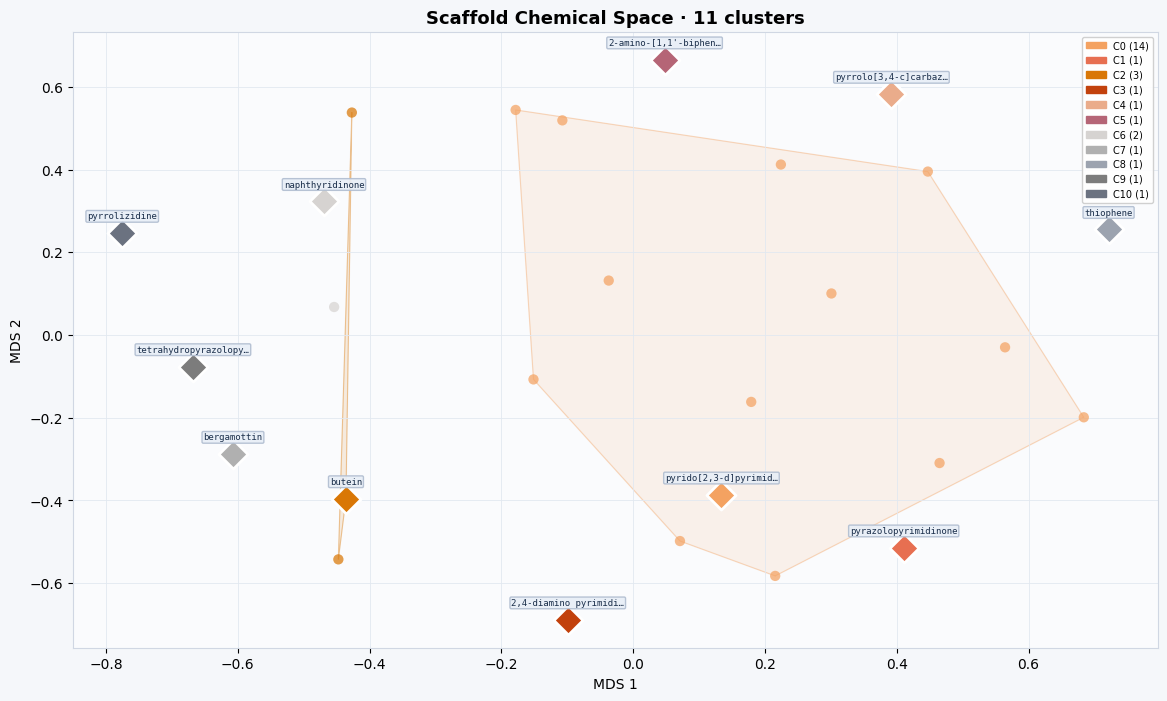

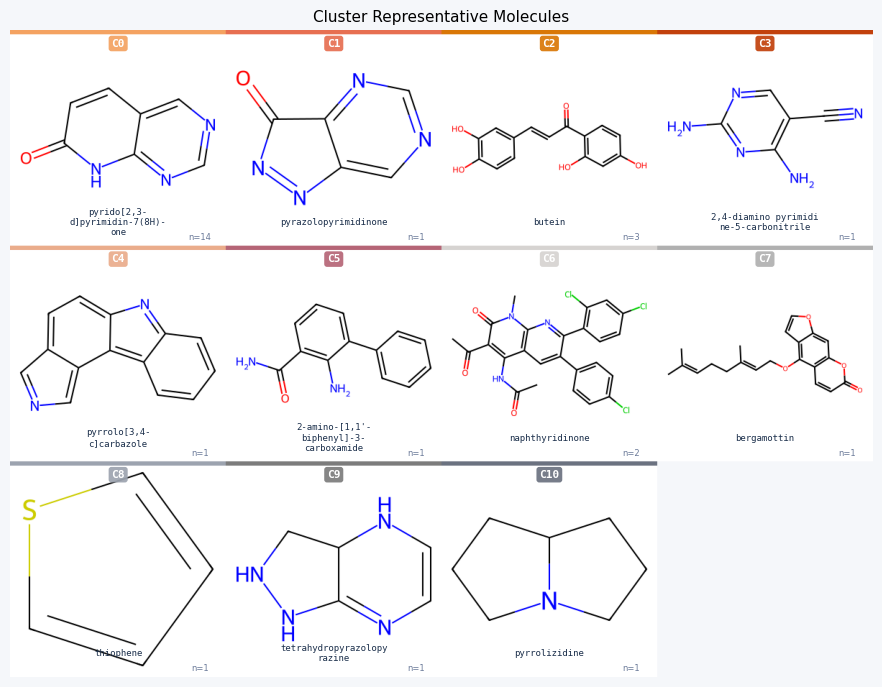

center scaffold:
 pyrido[2,3-d]pyrimidin-7(8H)-one : C1=CC(=O)NC2=NC=NC=C21


In [23]:
import src.scaffold_clustering as sc
import importlib
importlib.reload(sc)
from src.scaffold_clustering import run_clustering_pipeline


SIMILARITY_CUTOFF = 0.15  # Adjust as needed for cluster granularity
DR_METHOD = "mds"  # "mds" | "tsne" | "pca"
CSV_PATH = f"{TARGET_PROTEIN}/csvs/{TARGET_PROTEIN}_scaffolds_sorted.csv"


results = run_clustering_pipeline(
    protein_name = TARGET_PROTEIN,
    csv_path          = CSV_PATH,
    smiles_col        = "smiles",
    scaffold_col      = "scaffold",
    similarity_cutoff = SIMILARITY_CUTOFF,
    dr_method         = DR_METHOD,     # "mds" | "tsne" | "pca"
    mol_img_size      = (300, 300),
    mols_per_row      = 4,
    top_n_clusters    = None,      # None = show all clusters
    show_plots        = True,
)


center_smiles = results["center_smiles"]
center_sc_name = results["center_scaffold_name"]
clusters = results["clusters"]
mols_all = results["mols_all"]
print("center scaffold:\n", center_sc_name, ":", center_smiles)

**JSON: SCAFFOLD CLUSTERING**

In [149]:
# ── JSON: Scaffold Clustering ────────────────────────────────────────────────
# Image filenames from updated clustering code:
#   <TARGET>_scaffolds_sorted_scatter_<DR>.png   (chemical space map)
#   <TARGET>_scaffolds_sorted_cluster_centres.png (molecule grid)
import json, os, csv, shutil

_base = TARGET_PROTEIN
try: _dr = DR_METHOD
except NameError: _dr = "mds"

def _count_csv(path):
    try:
        with open(path, newline="", encoding="utf-8") as _f:
            return sum(1 for _ in csv.reader(_f)) - 1
    except: return 0

_cluster_csv = f"{_base}/csvs/{_base}_scaffolds_sorted_cluster_summary.csv"
os.makedirs(f"{_base}/images", exist_ok=True)

# ── Scatter / chemical-space map ──────────────────────────────────────────────
_scatter_src = f"{_base}/images/{_base}_scatter_{_dr}.png"
_scatter_dst = f"{_base}/images/scaffold_cluster_map.png"
# Fallbacks for older naming conventions
if not os.path.exists(_scatter_src):
    _scatter_src = f"{_base}/images/{_base}_scaffolds_sorted_clusters_{_dr}_map.png"
if not os.path.exists(_scatter_src):
    _scatter_src = f"{_base}/images/{_base}_scaffolds_sorted_clusters_{_dr}.png"
if os.path.exists(_scatter_src):
    shutil.copy2(_scatter_src, _scatter_dst)
    print(f"  Copied scatter map → {_scatter_dst}")
else:
    print(f"  Warning: cluster scatter image not found (tried {_scatter_src})")

# ── Molecule grid / cluster centres ───────────────────────────────────────────
_centres_src = f"{_base}/images/{_base}_cluster_centres.png"
_centres_dst = f"{_base}/images/scaffold_cluster_centers.png"
# Fallback for older naming
if not os.path.exists(_centres_src):
    _centres_src = f"{_base}/images/{_base}_scaffolds_sorted_clusters_{_dr}_centers.png"
if os.path.exists(_centres_src):
    shutil.copy2(_centres_src, _centres_dst)
    print(f"  Copied cluster centres → {_centres_dst}")
else:
    print(f"  Warning: cluster centres image not found")

try: _n_clusters = len(clusters); _n_mols = len(mols_all)
except NameError: _n_clusters = "—"; _n_mols = "—"
try: _sim_cutoff = str(SIMILARITY_CUTOFF)
except NameError: _sim_cutoff = "—"
try: _cname = center_sc_name
except NameError: _cname = "—"
try: _csmi = center_smiles
except NameError: _csmi = "—"

_cluster_section = {
    "title": "Scaffold Clustering",
    "sections": [
        {
            "heading": "Clustering Parameters",
            "type": "facts",
            "content": [
                {"label": "Dimensionality Reduction", "value": _dr.upper()},
                {"label": "Similarity Method",        "value": "Butina / Tanimoto"},
                {"label": "Fingerprint",              "value": "Morgan r=2, 2048 bits"},
                {"label": "Similarity Cutoff",        "value": _sim_cutoff},
                {"label": "Clusters Found",           "value": str(_n_clusters)},
                {"label": "Valid Molecules",          "value": str(_n_mols)},
            ]
        },
        {
            "heading": "Selected Central Scaffold",
            "type": "facts",
            "content": [
                {"label": "Scaffold Name",   "value": _cname},
                {"label": "SMILES",          "value": _csmi},
                {"label": "Cluster summary CSV",
                 "value": f"{_count_csv(_cluster_csv)} records — {_cluster_csv}"},
            ]
        },
        {
            "heading": "",
            "type": "text",
            "content": (
                "The cluster with the highest number of unique scaffolds was selected "
                "as the primary cluster. Its medoid — the molecule with the highest "
                "average Tanimoto similarity to all other cluster members — was chosen "
                "as the central scaffold for downstream scaffold hopping. The chemical "
                "space map shows all scaffolds coloured by cluster with convex hulls; "
                "the cluster centres panel shows the representative structure per cluster."
            )
        }
    ]
}

os.makedirs(f"{TARGET_PROTEIN}/sections", exist_ok=True)
with open(f"{TARGET_PROTEIN}/sections/13_clustering.json", "w", encoding="utf-8") as _f:
    json.dump(_cluster_section, _f, indent=2, ensure_ascii=False)
print(f"✓ Clustering JSON saved")


  Copied scatter map → GLP1R/images/scaffold_cluster_map.png
  Copied cluster centres → GLP1R/images/scaffold_cluster_centers.png
✓ Clustering JSON saved


**CHEMBL ACTIVITY PROCESSING**

In [4]:
import src.chembl_activity_processing as chap
importlib.reload(chap)

from src.chembl_activity_processing import run_ch_activity_pipeline


results = run_ch_activity_pipeline(
    target_protein     = TARGET_PROTEIN,
    file_path        = f"{TARGET_PROTEIN}/{TARGET_PROTEIN}_chembl.csv",  # optional override
    save_csv           = True,
)

# Quick access to key results:
df_clean       = results["df_clean"]
summary_counts = results["summary_counts"]
all_best_post  = results["all_best_post"]

studies_passing = summary_counts["studies_passing"] 
molecules_after_threshold = summary_counts["molecules_after_threshold"]
total_unique_molecules = results['total_unique_molecules']

stype_doc_counts = results['stype_doc_counts']
stype_mol_counts = results['stype_mol_counts']


print("Molecules after threshold:", summary_counts["molecules_after_threshold"])
print("Studies passing threshold:", summary_counts["studies_passing"])

Rows after cleaning           : 15,015
Unique molecules (before threshold): 15,015
Standard types found          : ['% Activity remaining', '% Control', '% Ctrl', '% Residual activity with Skepinone-L', '% binding', '% inhibition', '% of control', '% of engagement', '% of inhibition', '% residual kinase activity', 'Activity', 'Delta Tm', 'EC50', 'ED50', 'Effect', 'FC', 'IC50', 'INH', 'Imax', 'Inhibition', 'Kd', 'Ki', 'Occupancy', 'Ratio IC50', 'Residual Activity', 'Residual activity', 'activity']

Processing: IC50
  Documents before threshold : 186
  Documents after threshold  : 170
  Unique mols in surviving docs : 8472
  Saved: IRAK4/csvs/chembl_activity/IRAK4_chembl_most_potent_IC50.csv

Processing: Inhibition
  Documents before threshold : 159
  Documents after threshold  : 62
  Unique mols in surviving docs : 137
  Saved: IRAK4/csvs/chembl_activity/IRAK4_chembl_most_potent_Inhibition.csv

Processing: Kd
  Documents before threshold : 11
  Documents after threshold  : 9
  Unique mo

**JSON: CHEMBL ACTIVITY PROCESSING**

In [151]:
# ── JSON: ChEMBL Activity ────────────────────────────────────────────────────
import json, os, csv, shutil, re

_base = TARGET_PROTEIN
_report_txt = f"{_base}/txts/{_base}_chembl_activity_summary_report.txt"
_chart_src  = f"{_base}/images/{_base}_chembl_publications_per_year.png"
_chart_dst  = f"{_base}/images/chembl_pubs_per_year.png"

os.makedirs(f"{_base}/images", exist_ok=True)
if os.path.exists(_chart_src):
    shutil.copy2(_chart_src, _chart_dst)

# ── Threshold lookup (matches potency_thresholds in activity cell) ─────────────
_THRESHOLDS = {
    "IC50":       "<= 10,000 nM",
    "EC50":       "<= 10,000 nM",
    "Ki":         "<= 1,000 nM",
    "Kd":         "<= 1,000 nM",
    "XC50":       "<= 10,000 nM",
    "AC50":       "<= 10,000 nM",
    "ED50":       "<= 10,000 nM",
    "LD50":       ">= 1,000 nM",
    "Inhibition": ">= 50",
    "Activity":   ">= 50",
}

# ── Pull key numbers from in-memory variables ──────────────────────────────────
# Uses exact variable names from the activity cell:
#   total_unique_molecules     → ① molecules before threshold
#   molecules_after_threshold  → ④ molecules after threshold
#   studies_passing            → ② unique studies/documents passing
#   stype_doc_counts           → {stype: n_docs} after threshold
#   stype_mols_in_surviving_docs → {stype: n_mols} in surviving docs
#   all_best_dfs               → {stype: DataFrame} post-threshold

_mol_before = "—"
_mol_after  = "—"
_studies    = "—"

try:
    _mol_before = f"{total_unique_molecules:,}"
    _mol_after  = f"{molecules_after_threshold:,}"
    _studies    = f"{studies_passing:,}"

    print(f"  Molecules before threshold : {_mol_before}")
    print(f"  Molecules after threshold  : {_mol_after}")
    print(f"  Studies passing threshold  : {_studies}")

except NameError:
    print("  In-memory variables not found — falling back to txt report parsing.")
    if os.path.exists(_report_txt):
        with open(_report_txt, encoding="utf-8") as _f:
            for _line in _f:
                _line = _line.strip()
                if _line.startswith("Molecules before threshold"):
                    _m = re.search(r":\s*([\d,]+)", _line)
                    if _m: _mol_before = _m.group(1)
                elif _line.startswith("Molecules after threshold"):
                    _m = re.search(r":\s*([\d,]+)", _line)
                    if _m: _mol_after = _m.group(1)
                elif _line.startswith("Studies passing threshold"):
                    _m = re.search(r":\s*([\d,]+)", _line)
                    if _m: _studies = _m.group(1)
        print(f"  Parsed from txt — before: {_mol_before}, after: {_mol_after}, studies: {_studies}")
    else:
        print(f"  Warning: {_report_txt} not found — stat tiles will show '—'")

# ── Per-stype threshold table ──────────────────────────────────────────────────
# Columns: Standard Type | Threshold | Docs (passed) | Mols in surviving docs
_stype_table_rows = [["Standard Type", "Threshold", "Docs (passed)", "Mols in docs"]]

try:
    # Live path: use stype_doc_counts + stype_mols_in_surviving_docs directly
    for _stype in sorted(stype_doc_counts.keys()):
        _thresh   = _THRESHOLDS.get(_stype, "—")
        _n_docs   = f"{stype_doc_counts[_stype]:,}"
        _n_mols   = f"{stype_mol_counts.get(_stype, 0):,}"
        _stype_table_rows.append([_stype, _thresh, _n_docs, _n_mols])

except NameError:
    # Fallback: parse from txt report
    # Line format: "  IC50            393          8,419  <= 10,000 nM"
    if os.path.exists(_report_txt):
        with open(_report_txt, encoding="utf-8") as _f:
            for _line in _f:
                _parts = _line.split()
                if _parts and _parts[0] in _THRESHOLDS:
                    _stype  = _parts[0]
                    _thresh = _THRESHOLDS[_stype]
                    _nums   = re.findall(r"[\d,]+", _line)
                    # txt layout: stype | n_docs | n_mols | threshold
                    _n_docs = _nums[0] if len(_nums) > 0 else "—"
                    _n_mols = _nums[1] if len(_nums) > 1 else "—"
                    _stype_table_rows.append([_stype, _thresh, _n_docs, _n_mols])
    if len(_stype_table_rows) == 1:
        _stype_table_rows.append(["Re-run ChEMBL activity cell to populate", "—", "—", "—"])

# ── Text blocks ────────────────────────────────────────────────────────────────
_intro_text = (
    "This section summarizes molecular activity data reported in ChEMBL across "
    "multiple activity metrics. It highlights publication trends over time for the "
    "target, quantifies the number of studies/documents associated with each metric, "
    "and includes scaffold-level information for molecules reported in each document "
    "within the accompanying CSV files."
)

_threshold_note = (
    "Activity thresholds are applied to retain only studies whose most potent "
    "molecule meets a minimum activity criterion — studies where even the best "
    "molecule fails to reach this bar are excluded from downstream analysis. "
    "'Mols in docs' counts all unique molecules across surviving documents for "
    "that standard type, not just the single best molecule selected per document."
)

# ── Assemble section JSON ──────────────────────────────────────────────────────
_activity_section = {
    "title": "ChEMBL Activity Data Processing",
    "sections": [
        {
            "heading": "",
            "type": "intro_text",
            "content": _intro_text
        },
        {
            "heading": "",
            "type": "stat_tiles",
            "content": [
                {"label": "Molecules in",          "value": _mol_before},
                {"label": "Molecules after filter", "value": _mol_after},
                {"label": "Studies passing",        "value": _studies},
            ]
        },
        {
            "heading": "Activity Thresholds & Record Counts",
            "type": "table",
            "content": _stype_table_rows,
            "col_fracs": [0.20, 0.30, 0.25, 0.25]
        },
        {
            "heading": "",
            "type": "source_note",
            "content": _threshold_note
        },
    ]
}

os.makedirs(f"{TARGET_PROTEIN}/sections", exist_ok=True)
with open(f"{TARGET_PROTEIN}/sections/14_chembl_activity.json", "w", encoding="utf-8") as _f:
    json.dump(_activity_section, _f, indent=2, ensure_ascii=False)
print(f"\n✓ ChEMBL activity JSON saved")
print(f"  Stat tiles → before: {_mol_before} | after: {_mol_after} | studies: {_studies}")
print(f"  Threshold table → {len(_stype_table_rows)-1} standard type(s)")

  Molecules before threshold : 112,611
  Molecules after threshold  : 1,897
  Studies passing threshold  : 87

✓ ChEMBL activity JSON saved
  Stat tiles → before: 112,611 | after: 1,897 | studies: 87
  Threshold table → 6 standard type(s)


**SCAFFOLD HOPPING AND FRAGMENT REPLACEMENT**

- Identifying the most potent molecule from the IC50 stype that has the highest similarity to the center scaffold

- Scaffold hopping of the most potent mol from the chembl activity data and the selected refs

- Performing fragment replacement on the hopped molecules

In [27]:
import src.scaffold_hop_frag_repl as shfr
import importlib
importlib.reload(shfr)
from src.scaffold_hop_frag_repl import ph_similarity_pipeline, align_and_visualize
import pandas as pd

chembl_ic50_df = pd.read_csv(f"{TARGET_PROTEIN}/csvs/chembl_activity/{TARGET_PROTEIN}_chembl_most_potent_IC50.csv")
chembl_ic50_df["central_scaffold_coverage"] = None
chembl_ic50_df["rmsd"] = None

scaffold_smiles = center_smiles

for i, row in chembl_ic50_df.iterrows():
    ref_smiles = row["Smiles"]
    ph1_result = ph_similarity_pipeline(
    ref_smiles=ref_smiles,
    query_smiles=scaffold_smiles,
    )
    # After align_and_visualize
    align_result = align_and_visualize(
        pipeline_result = ph1_result,
        ref_smiles = ref_smiles,    
        query_smiles = scaffold_smiles,
        output_path    = None,
        show_alignment = False,
    )

    _,_,_, rmsd,_,region_info = align_result
    scaffold_coverage = region_info['query_coverage'] 

    chembl_ic50_df.at[i, "central_scaffold_coverage"] = scaffold_coverage
    chembl_ic50_df.at[i, "rmsd"] = rmsd

chembl_ic50_df["central_scaffold_coverage"] = (
    chembl_ic50_df["central_scaffold_coverage"]
    .str.replace("%", "", regex=False)
        .astype(float)
)

  [Hop-buffer filter] 7 → 7 entries kept (hop_buffer=2, cost_threshold=6.5)
  Merged matches after sync : 7 (ref_nodes: [13, 7, 6, 16, 2, 25, 15])
  [Enclosure fill] Pulled enclosed ref atom 27
  [Ring completion] Completed ring [5, 6, 12, 13, 25], added atoms [5, 6]
  [Fusion neighbor] Ring [6, 7, 8, 9, 11, 12] is a fused neighbor — pulled in atoms [7, 8, 9, 11]
  Gap-fill boundary atom 5 proxied → ref matched atom 25 → query atom 9
  Gap-fill boundary atom 9 proxied → ref matched atom 12 → query atom 5

ATOM ALIGNMENT REPORT (deduplicated)

  Feature match: ref_node=13 (HP) ↔ query_node=7 (HP)  [Pass 1]
    ref atom  14 (C) ↔ query atom  10 (C)  dist = 1.421 Å

  Feature match: ref_node=7 (AR) ↔ query_node=6 (AR)  [Pass 1]
    ref atom  25 (C) ↔ query atom   9 (C)  dist = 0.892 Å
    ref atom  12 (C) ↔ query atom   5 (C)  dist = 3.492 Å

  Feature match: ref_node=6 (HBA) ↔ query_node=2 (HBA)  [Pass 1]
    ref atom  30 (O) ↔ query atom   3 (O)  dist = 0.656 Å

  Feature match: ref_nod


Processing two reference molecules.

Processing reference molecule 1
CN1C(=O)[C@@H](N2CCc3cn(CC4CCS(=O)(=O)CC4)nc3C2=O)COc2ccccc21
Reference Name: CHEMBL4097778
  [Hop-buffer filter] 7 → 7 entries kept (hop_buffer=8, cost_threshold=6.5)
  Merged matches after sync : 7 (ref_nodes: [4, 9, 6, 0, 13, 5, 7])
  Gap-fill boundary atom 4 proxied → ref matched atom 5 → query atom 4
  Gap-fill boundary atom 10 proxied → ref matched atom 9 → query atom 0


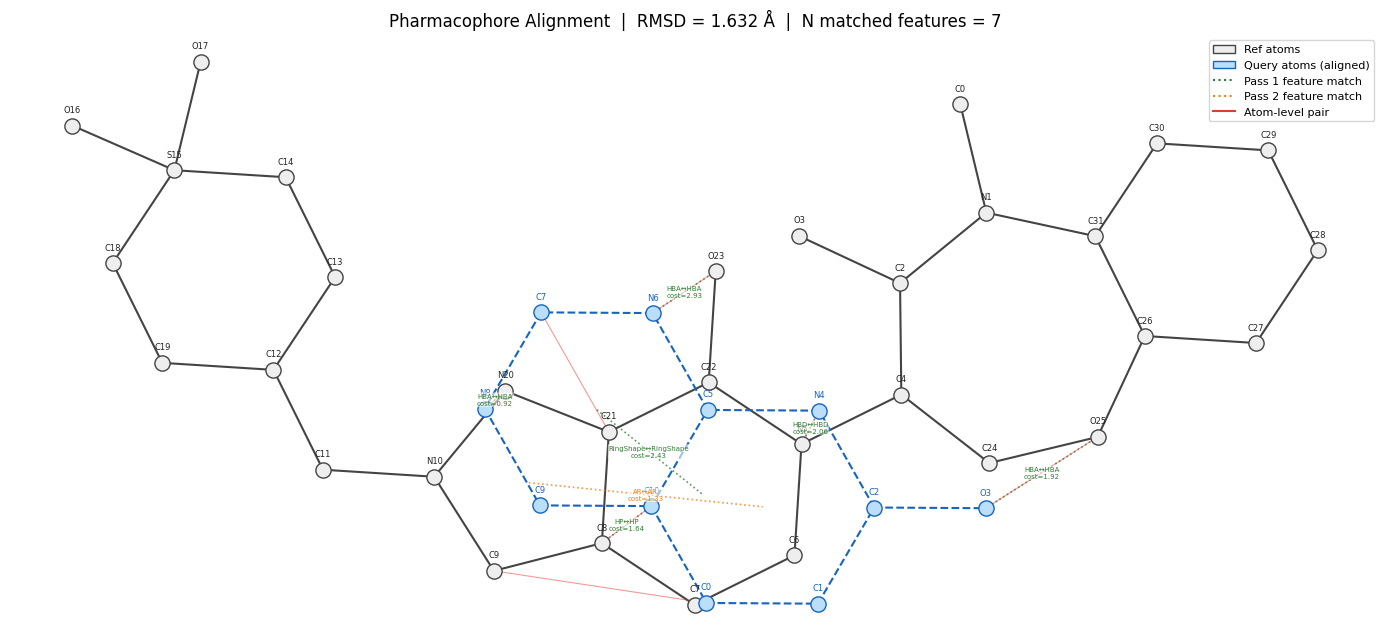

Saved to alignment.png

ATOM ALIGNMENT REPORT (deduplicated)

  Feature match: ref_node=4 (HBA) ↔ query_node=4 (HBA)  [Pass 1]
    ref atom  20 (N) ↔ query atom   8 (N)  dist = 0.364 Å

  Feature match: ref_node=9 (HP) ↔ query_node=7 (HP)  [Pass 1]
    ref atom   8 (C) ↔ query atom  10 (C)  dist = 0.832 Å

  Feature match: ref_node=6 (HBA) ↔ query_node=2 (HBA)  [Pass 1]
    ref atom  25 (O) ↔ query atom   3 (O)  dist = 1.786 Å

  Feature match: ref_node=0 (HBD) ↔ query_node=0 (HBD)  [Pass 1]
    ref atom   5 (N) ↔ query atom   4 (N)  dist = 0.509 Å

  Feature match: ref_node=13 (RingShape) ↔ query_node=9 (RingShape)  [Pass 1]
    ref atom  21 (C) ↔ query atom   7 (C)  dist = 1.850 Å

  Feature match: ref_node=5 (HBA) ↔ query_node=3 (HBA)  [Pass 1]
    ref atom  23 (O) ↔ query atom   6 (N)  dist = 1.020 Å

  Feature match: ref_node=7 (AR) ↔ query_node=5 (AR)  [Pass 2]
    ref atom   9 (C) ↔ query atom   0 (C)  dist = 2.893 Å

  Overall centroid RMSD: 1.6319 Å

REPLACEABLE REGION
  Match

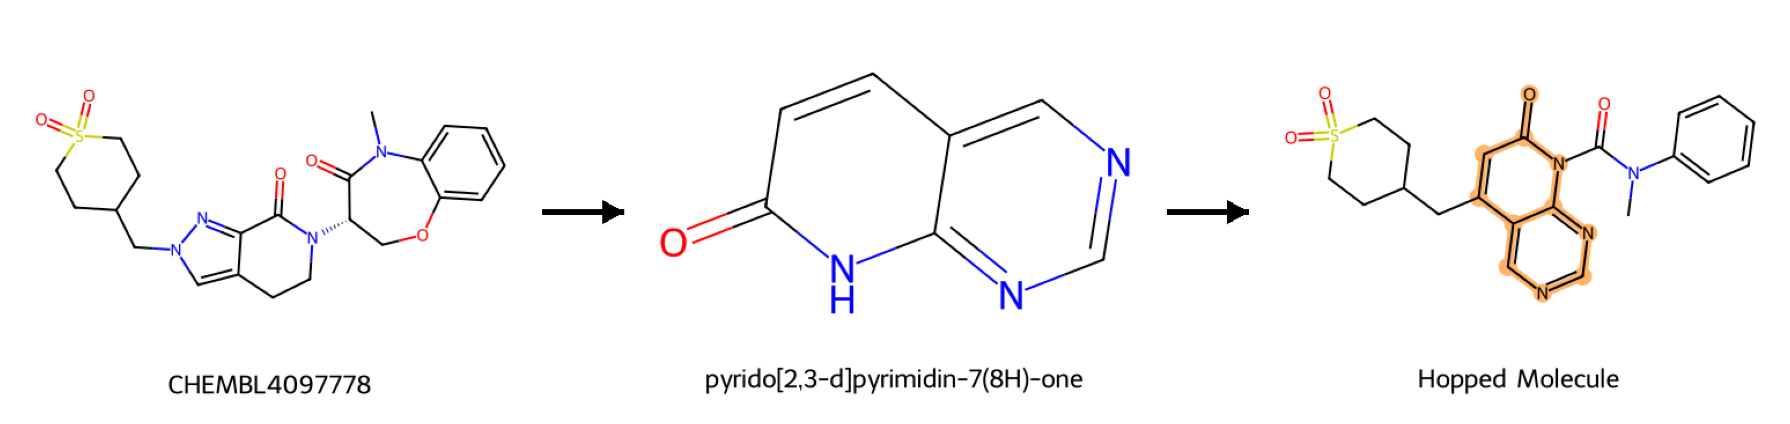


Saved progression image → WEE1/images/CHEMBL4097778_scaffold_hopped.png

Processing reference molecule 2
C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-c1cccc(C(C)(C)O)n1
Reference Name: ADAVOSERTIB
  Merged matches after sync : 4 (ref_nodes: [10, 13, 16, 3])


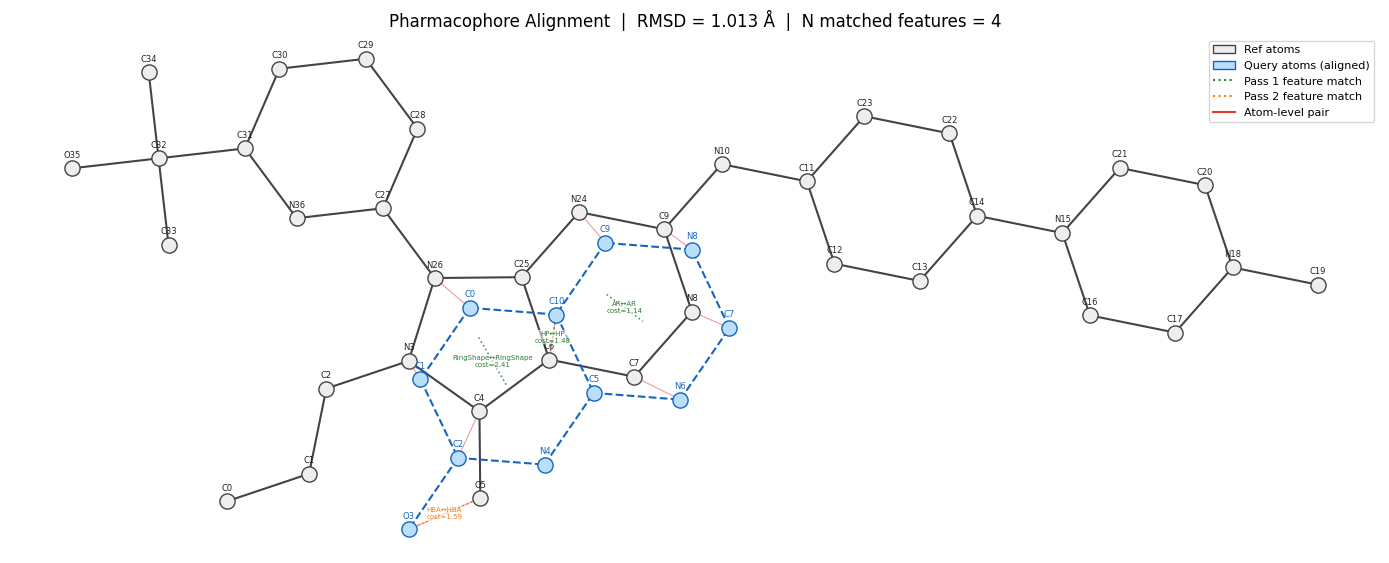

Saved to alignment.png

ATOM ALIGNMENT REPORT (deduplicated)

  Feature match: ref_node=10 (AR) ↔ query_node=6 (AR)  [Pass 1]
    ref atom   9 (C) ↔ query atom   8 (N)  dist = 0.594 Å
    ref atom  24 (N) ↔ query atom   9 (C)  dist = 0.700 Å
    ref atom   8 (N) ↔ query atom   7 (C)  dist = 0.708 Å
    ref atom   7 (C) ↔ query atom   6 (N)  dist = 0.886 Å

  Feature match: ref_node=13 (HP) ↔ query_node=7 (HP)  [Pass 1]
    ref atom   6 (C) ↔ query atom  10 (C)  dist = 0.786 Å

  Feature match: ref_node=16 (RingShape) ↔ query_node=8 (RingShape)  [Pass 1]
    ref atom   3 (N) ↔ query atom   1 (C)  dist = 0.379 Å
    ref atom  26 (N) ↔ query atom   0 (C)  dist = 0.792 Å
    ref atom   4 (C) ↔ query atom   2 (C)  dist = 0.885 Å

  Feature match: ref_node=3 (HBA) ↔ query_node=2 (HBA)  [Pass 2]
    ref atom   5 (O) ↔ query atom   3 (O)  dist = 1.348 Å

  Overall centroid RMSD: 1.0133 Å

REPLACEABLE REGION
  Matched ref atoms  : [3, 4, 5, 6, 7, 8, 9, 24, 26]
  Replaceable atoms  : [3, 4, 5, 6

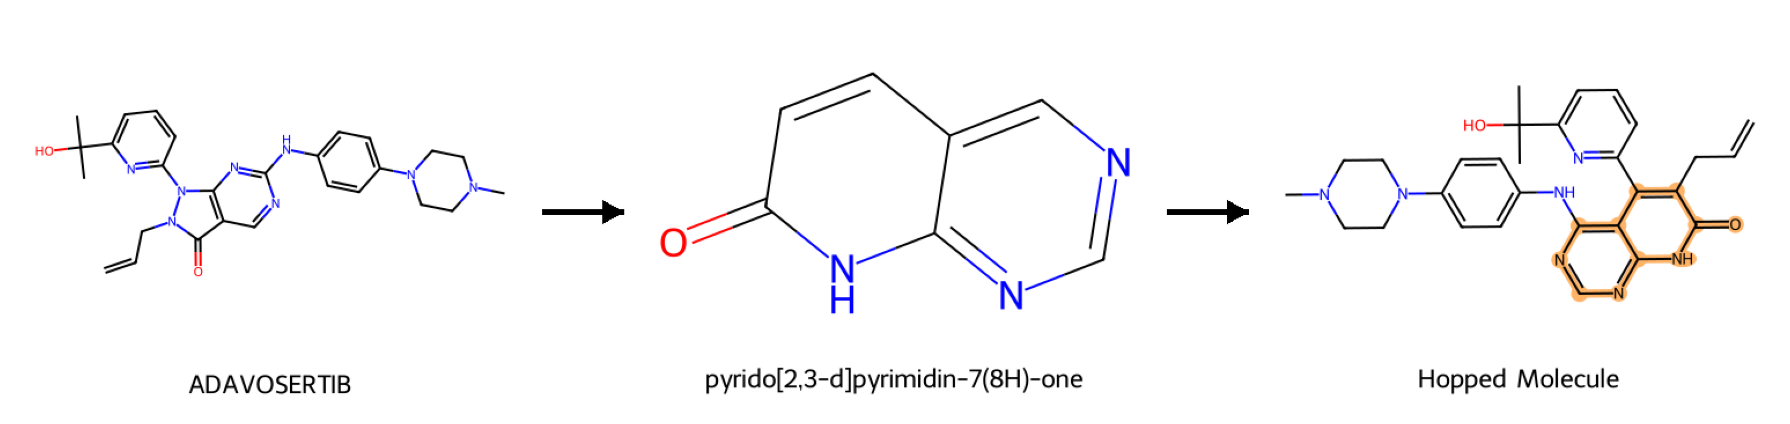


Saved progression image → WEE1/images/ADAVOSERTIB_scaffold_hopped.png

Processing reference molecule 3
C=CCn1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc2n1-c1ccc2c(n1)[C@@](O)(CC)CC2
Reference Name: AZENOSERTIB
  [Hop-buffer filter] 3 → 3 entries kept (hop_buffer=8, cost_threshold=6.5)
  Merged matches after sync : 3 (ref_nodes: [10, 13, 3])
  [Ring completion] Completed ring [3, 4, 6, 25, 26], added atoms [3, 26]
  Gap-fill boundary atom 3 proxied → ref matched atom 5 → query atom 3
  Gap-fill boundary atom 26 proxied → ref matched atom 6 → query atom 10


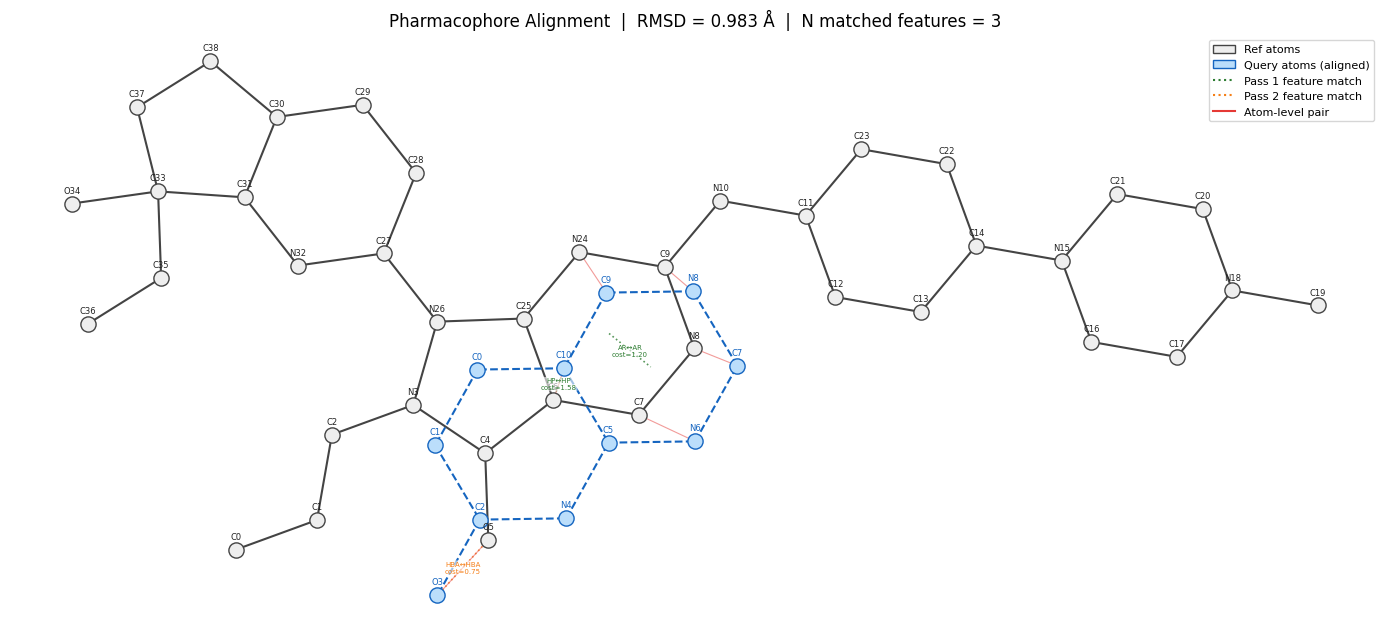

Saved to alignment.png

ATOM ALIGNMENT REPORT (deduplicated)

  Feature match: ref_node=10 (AR) ↔ query_node=6 (AR)  [Pass 1]
    ref atom   9 (C) ↔ query atom   8 (N)  dist = 0.644 Å
    ref atom   8 (N) ↔ query atom   7 (C)  dist = 0.801 Å
    ref atom  24 (N) ↔ query atom   9 (C)  dist = 0.842 Å
    ref atom   7 (C) ↔ query atom   6 (N)  dist = 1.078 Å

  Feature match: ref_node=13 (HP) ↔ query_node=7 (HP)  [Pass 1]
    ref atom   6 (C) ↔ query atom  10 (C)  dist = 0.578 Å

  Feature match: ref_node=3 (HBA) ↔ query_node=2 (HBA)  [Pass 2]
    ref atom   5 (O) ↔ query atom   3 (O)  dist = 1.301 Å

  Overall centroid RMSD: 0.9828 Å

REPLACEABLE REGION
  Matched ref atoms  : [5, 6, 7, 8, 9, 24]
  Replaceable atoms  : [3, 4, 5, 6, 7, 8, 9, 24, 25, 26]
  Boundary atoms     : [3, 9, 26]
  Boundary→Query map : {3: 3, 9: 8, 26: 10}
  Coverage of Query  : 42.86%, Total Nodes: 7, Matched: 3

FRAGMENT TRANSPLANTATION
  Replaceable region : [3, 4, 5, 6, 7, 8, 9, 24, 25, 26]
  Boundary atoms     

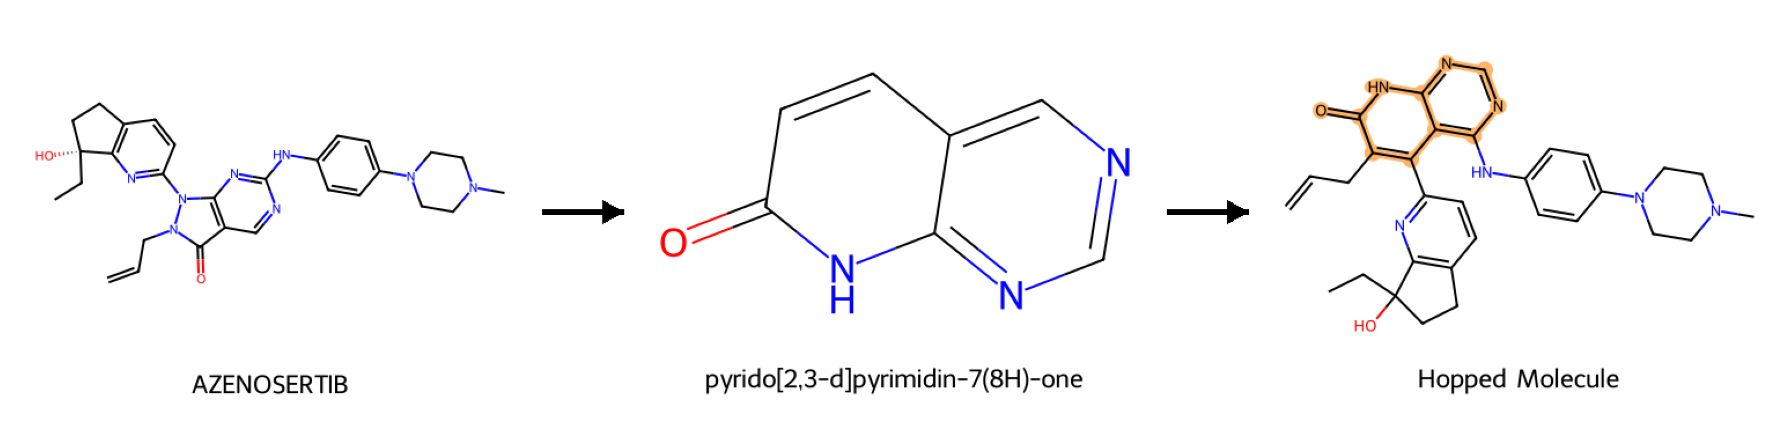


Saved progression image → WEE1/images/AZENOSERTIB_scaffold_hopped.png


SCAFFOLD HOPPING SUMMARY

Result 1
Reference: CHEMBL4097778
Hopped SMILES: CN(C(=O)n1c(=O)cc(CC2CCS(=O)(=O)CC2)c2cncnc21)c1ccccc1
Image: WEE1/images/CHEMBL4097778_scaffold_hopped.png

Result 2
Reference: ADAVOSERTIB
Hopped SMILES: C=CCc1c(-c2cccc(C(C)(C)O)n2)c2c(Nc3ccc(N4CCN(C)CC4)cc3)ncnc2[nH]c1=O
Image: WEE1/images/ADAVOSERTIB_scaffold_hopped.png

Result 3
Reference: AZENOSERTIB
Hopped SMILES: C=CCc1c(-c2ccc3c(n2)C(O)(CC)CC3)c2c(Nc3ccc(N4CCN(C)CC4)cc3)ncnc2[nH]c1=O
Image: WEE1/images/AZENOSERTIB_scaffold_hopped.png


In [31]:
import src.scaffold_hop_frag_repl as shfr
importlib.reload(shfr)
from src.scaffold_hop_frag_repl import * #ph_similarity_pipeline, align_and_visualize,build_hopped_scaffold,draw_scaffold_hop
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import os

ref_file = f"{TARGET_PROTEIN}/csvs/{TARGET_PROTEIN}_selected_ref_molecules.csv"

# ═══════════════════════════════════════════════════════════════════════
# Check if file exists
# ═══════════════════════════════════════════════════════════════════════

if os.path.exists(ref_file):

    ref_df = pd.read_csv(ref_file)

    ref_df = ref_df.drop_duplicates(
        subset=["canonical_smiles"]
    )
    ref_df_f2 = (
        ref_df
        .sort_values(by="on_target_best_pchembl", ascending=False)
        .head(2)
    )
    if len(ref_df_f2) == 0:

        raise ValueError(
            "No reference molecules found in selected_ref_molecules.csv"
        )

    elif len(ref_df_f2) == 1:

        print("\nOnly one reference molecule found.")

    else:

        print("\nProcessing two reference molecules.")

else:

    print(f"\n⚠️ Missing file: {ref_file}")

    ref_df_f2 = pd.DataFrame(
        columns=["canonical_smiles", "pref_name"]
    )

# ═══════════════════════════════════════════════════════════════════════
# Combining Ref + ChemBL for Scaffold Hopping
# ═══════════════════════════════════════════════════════════════════════

chembl_ic50_df = chembl_ic50_df.sort_values(
    by=["central_scaffold_coverage", "rmsd"],
    ascending=[False, True]
)

chembl_ref_smiles = chembl_ic50_df.iloc[0]["Smiles"]
chembl_ref_id = chembl_ic50_df.iloc[0]["Molecule ChEMBL ID"]

ref_df = ref_df_f2[['canonical_smiles', 'pref_name']]

new_row = pd.DataFrame([{
    "canonical_smiles": chembl_ref_smiles,
    "pref_name": chembl_ref_id,
}])

ref_df = pd.concat(
    [new_row, ref_df],
    ignore_index=True
)


# ═══════════════════════════════════════════════════════════════════════
# PROCESS EACH REFERENCE MOLECULE
# ═══════════════════════════════════════════════════════════════════════

all_hopped_results = []
out_paths = []
scaffold_smiles = center_smiles


for idx, row in ref_df.iterrows():

    print("\n" + "=" * 70)
    print(f"Processing reference molecule {idx + 1}")
    print("=" * 70)

    # -----------------------------------------------------------------
    # Reference molecule info
    # -----------------------------------------------------------------

    ref_smiles = row["canonical_smiles"]
    print(ref_smiles)

    ref_name = (
        row["pref_name"]
        if pd.notna(row["pref_name"])
        else f"Reference_{idx+1}"
    )

    print(f"Reference Name: {ref_name}")

    # -----------------------------------------------------------------
    # Pharmacophore similarity
    # -----------------------------------------------------------------

    ph1_result = ph_similarity_pipeline(
        ref_smiles=ref_smiles,
        query_smiles=scaffold_smiles,
    )

    # -----------------------------------------------------------------
    # Alignment
    # -----------------------------------------------------------------

    align_result = align_and_visualize(
        pipeline_result=ph1_result,
        ref_smiles=ref_smiles,
        query_smiles=scaffold_smiles,
        output_path="alignment.png",
        show_alignment=True,
    )

    (
        R,
        t,
        atom_mapping,
        rmsd,
        query_coords_aligned,
        region_info,
    ) = align_result

    # -----------------------------------------------------------------
    # Build molecules
    # -----------------------------------------------------------------

    ref_mol = Chem.MolFromSmiles(ref_smiles)
    query_mol = Chem.MolFromSmiles(scaffold_smiles)

    # Skip invalid reference/query molecules
    if ref_mol is None:
        print(f"[SKIPPED] Invalid reference SMILES: {ref_smiles}")
        continue

    if query_mol is None:
        print(f"[SKIPPED] Invalid scaffold SMILES: {scaffold_smiles}")
        continue

    AllChem.Compute2DCoords(ref_mol)
    AllChem.Compute2DCoords(query_mol)

    # -----------------------------------------------------------------
    # Scaffold hopping
    # -----------------------------------------------------------------

    (
        hopped_mol_smi,
        attachment_log,
        failed_log,
        fragment_map,
    ) = build_hopped_scaffold(
        align_result=(
            R,
            t,
            atom_mapping,
            rmsd,
            region_info,
        ),
        region_info=region_info,
        ref_mol=ref_mol,
        query_mol=query_mol,
        query_coords_aligned=query_coords_aligned,
    )

    print(f"\nGenerated hopped molecule:\n{hopped_mol_smi}")

    # -----------------------------------------------------------------
    # Validate hopped molecule
    # -----------------------------------------------------------------

    # Case 1: None / empty output
    if hopped_mol_smi is None or str(hopped_mol_smi).strip() == "":
        print(
            f"[REMOVED] No hopped molecule generated for {ref_name}"
        )
        continue

    # Case 2: Invalid SMILES
    hopped_mol = Chem.MolFromSmiles(hopped_mol_smi)

    if hopped_mol is None:
        print(
            f"[REMOVED] Invalid hopped SMILES for {ref_name}: "
            f"{hopped_mol_smi}"
        )
        continue

    # Case 3: Sanitization failure
    try:
        Chem.SanitizeMol(hopped_mol)
    except Exception as e:
        print(
            f"[REMOVED] Sanitization failed for {ref_name}: "
            f"{e}"
        )
        continue

    # Optional additional quality checks
    if hopped_mol.GetNumAtoms() == 0:
        print(
            f"[REMOVED] Empty molecule generated for {ref_name}"
        )
        continue

    # Canonicalize valid molecule
    hopped_mol_smi = Chem.MolToSmiles(
        hopped_mol,
        canonical=True
    )

    print(f"[VALID] Proceeding with hopped molecule")

    # -----------------------------------------------------------------
    # Draw progression image
    # -----------------------------------------------------------------

    out_path = (
        f"{TARGET_PROTEIN}/images/"
        f"{ref_name}_scaffold_hopped.png"
    )

    canvas = draw_scaffold_hop(
        ref_smiles=ref_smiles,
        scaffold_smiles=scaffold_smiles,
        hopped_smiles=hopped_mol_smi,
        ref_label=ref_name,
        scaffold_label=center_sc_name,
        hopped_label="Hopped Molecule",
        save_path=out_path,
    )

    out_paths.append(out_path)

    print(f"\nSaved progression image → {out_path}")

    # -----------------------------------------------------------------
    # Store results
    # -----------------------------------------------------------------

    all_hopped_results.append({
        "reference_id": ref_name,
        "reference_smiles": ref_smiles,
        "hopped_smiles": hopped_mol_smi,
        "attachment_log": attachment_log,
        "failed_log": failed_log,
        "fragment_map": fragment_map,
        "image_path": out_path,
    })


# ═══════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════

print("\n")
print("=" * 70)
print("SCAFFOLD HOPPING SUMMARY")
print("=" * 70)

for i, result in enumerate(all_hopped_results, start=1):

    print(f"\nResult {i}")
    print(f"Reference: {result['reference_id']}")
    print(f"Hopped SMILES: {result['hopped_smiles']}")
    print(f"Image: {result['image_path']}")

In [17]:
from src.scaffold_hop_frag_repl import (process_fragments, calc_props, process_and_save_similar_fragments,
                                         prepare_fragments,generate_final_molecules,att_to_c_conversion)

import numpy as np
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Draw
import itertools

#══════════════════════════════════════════════════════════════════════
#INPUT DATA
#══════════════════════════════════════════════════════════════════════

output_dir = f"{TARGET_PROTEIN}/generated"
Min_molecules = 1000

scaffold_smiles = center_smiles
scaffold_name = center_sc_name



ref_replacement = {}

for items in all_hopped_results:
    ref_name = items["reference_id"]
    ref_smiles = items["reference_smiles"]
    fragment_map = items["fragment_map"]

    mol_name = f"{ref_name}_{scaffold_name}"

    #Fragment replacement
    frag_desc_file = Path("Fragments_library_desc.csv")
    if not frag_desc_file.exists():
        fragment_df = pd.read_csv("Fragment_library.csv")
        fragment_df = fragment_df.drop_duplicates(subset="Fragments")
        fragment_df = fragment_df.dropna(subset='Fragments')
        fragment_df = fragment_df[fragment_df['Fragments'].str.contains(r"\[[^\]]*\*[^\]]*\]", regex=True, na=False)]
        fragment_desc = process_fragments(fragment_df, calc_props)
        fragment_desc.to_csv(frag_desc_file, index=False)
        print("File created.")
    else:
        fragment_desc = pd.read_csv(frag_desc_file)
        print("File already exists. Skipping.")


    # Find similar fragments from library
    frag_repl = fragment_map

    
    # Fragment cut off
    cutoff = cutoff = int(
    np.ceil(Min_molecules ** (1 / len(frag_repl))))
    print(f"Fragment replacement cutoff: {cutoff} similar fragments per replaced fragment")
                 

    similar_dfs = process_and_save_similar_fragments(frag_repl, fragment_desc, cutoff)
    index_dict = {}

    for k, v in similar_dfs.items():
        similar_dfs[k] = prepare_fragments(v)
        index_dict[k] = similar_dfs[k].index.to_list()

    # Generate all combinations
    combinations = list(itertools.product(*index_dict.values()))

    # Generate final molecules
    final_mol_df = generate_final_molecules(combinations, Chem.MolFromSmiles(scaffold_smiles), similar_dfs,att_to_c_conversion)
    final_mol_df.to_csv(f"{output_dir}/{scaffold_name}_{ref_name}_FARE_generated_molecules.csv", index=False)
    print(f"Generated {len(final_mol_df)} molecules for {ref_name} and saved to {output_dir}/{scaffold_name}_{ref_name}_FARE_generated_molecules.csv")

File already exists. Skipping.
Fragment replacement cutoff: 32 similar fragments per replaced fragment
Generated 2068 molecules for CHEMBL4568087 and saved to IRAK4/generated/quinazoline_CHEMBL4568087_FARE_generated_molecules.csv
File already exists. Skipping.
Fragment replacement cutoff: 10 similar fragments per replaced fragment
Generated 5472 molecules for ZIMLOVISERTIB and saved to IRAK4/generated/quinazoline_ZIMLOVISERTIB_FARE_generated_molecules.csv
File already exists. Skipping.
Fragment replacement cutoff: 1000 similar fragments per replaced fragment
Generated 1456 molecules for EMAVUSERTIB and saved to IRAK4/generated/quinazoline_EMAVUSERTIB_FARE_generated_molecules.csv


**JSON: SCAFFOLD HOPPING AND FRAGMENT REPLACEMENT**

In [18]:
# ── JSON: Scaffold Hopping & Fragment Replacement ────────────────────────────
import json, os, csv, glob, shutil

_base = TARGET_PROTEIN
output_dir = f"{_base}/generated"

def _count_csv(path):
    try:
        with open(path, newline="", encoding="utf-8") as _f:
            return sum(1 for _ in csv.reader(_f)) - 1
    except: return 0

# ── Collect hopping progression images from all_hopped_results ───────────────
# Uses the exact paths stored during hopping — no glob, no over-counting.
_hop_image_sections = []
try:
    
    for _result in all_hopped_results:
        
        _png  = _result.get("image_path", "")
        _rname = _result.get("reference_id", "")
        if _png and os.path.exists(_png):
            _hop_image_sections.append({
                "ref_name": _rname,
                "image_path": f"images/{os.path.basename(_png)}",
            })
    print(f"  Found {len(_hop_image_sections)} hopping image(s) from all_hopped_results")
except NameError:
    # Fallback if all_hopped_results not in scope
    for _png in sorted(glob.glob(f"{_base}/images/*_scaffold_hopped.png")):
        _rname = os.path.basename(_png).replace("_scaffold_hopped.png", "")
        _hop_image_sections.append({
            "ref_name":   _rname,
            "image_path": f"images/{os.path.basename(_png)}",
        })
    print(f"  Fallback glob: found {len(_hop_image_sections)} hopping image(s)")

# ── Collect FARE generated molecule CSVs ─────────────────────────────────────
_fare_csvs = sorted(glob.glob(f"{output_dir}/*_FARE_generated_molecules.csv"))
_fare_rows = [["CSV File", "Path", "Molecules Generated"]]
for _p in _fare_csvs:
    _fare_rows.append([
        os.path.basename(_p),
        _p,
        str(_count_csv(_p)),
    ])

# ── Assemble section JSON ─────────────────────────────────────────────────────
_sections = []

# 1. Scaffold hopping intro text (no heading — flows directly after section header)
_sections.append({
    "heading": "",
    "type": "text",
    "content": (
        "The central scaffold identified from the clustering analysis was selected "
        "for scaffold hopping. Molecules from the ChEMBL IC50 dataset exhibiting the "
        "highest scaffold pharmacophore similarity to the central scaffold, along with "
        "selected reference molecules from the approved/investigational compounds list, "
        "were used as the basis for the scaffold hopping process."
    )
})

# 2. One inline image per reference molecule — no label text, just image + caption
for _hi in _hop_image_sections:
    _sections.append({
        "heading": "",
        "type": "inline_image",
        "content": {
            "path":           _hi["image_path"],
            "caption":        f"Scaffold hop: {_hi['ref_name']}",
            "width_fraction": 1.0,
            "height_mm":      55,
        }
    })

# 3. Fragment replacement intro
_sections.append({
    "heading": "Fragment Replacement (FARE)",
    "type": "text",
    "content": (
        "Fragments with physicochemical properties similar to those already present "
        "were extracted from the fragment library and attached to the scaffold using "
        "the selected molecule as the reference framework."
    )
})

# 4. FARE CSV table (File | Path | Molecules Generated)
if len(_fare_rows) > 1:
    _sections.append({
        "heading": "Generated Molecule Files",
        "type": "table",
        "content": _fare_rows
    })
else:
    _sections.append({
        "heading": "",
        "type": "text",
        "content": "No FARE-generated molecule CSVs found. Re-run the fragment replacement cell."
    })

_hopping_section = {
    "title": "Scaffold Hopping & Fragment Replacement",
    "sections": _sections
}

os.makedirs(f"{TARGET_PROTEIN}/sections", exist_ok=True)
with open(f"{TARGET_PROTEIN}/sections/15_scaffold_hopping.json", "w", encoding="utf-8") as _f:
    json.dump(_hopping_section, _f, indent=2, ensure_ascii=False)
print(f"✓ Scaffold hopping JSON saved ({len(_hop_image_sections)} hop images, {len(_fare_rows)-1} FARE CSVs)")


  Found 3 hopping image(s) from all_hopped_results
✓ Scaffold hopping JSON saved (3 hop images, 3 FARE CSVs)


**JSON: METADATA**

In [19]:
# ── Master report_metadata.json ─────────────────────────────────────────────
import json, os
from datetime import datetime

_base = TARGET_PROTEIN
_W = 174   # CONTENT_W in mm

# Sponsor / collab chart height
# Matplotlib figure: figsize=(11, rows*2.6+0.4), so aspect = (rows*2.6)/11
# Expressed as mm of content width:  height_mm = W * (rows*2.6) / 11
try: _n_sp = len(_ct_data["top_sponsors"]); _n_co = len(_ct_data["top_collabs"])
except NameError: _n_sp = _n_co = 3
_sp_rows = max(1, (_n_sp + 2) // 3)
_co_rows = max(1, (_n_co + 2) // 3)
_sp_h    = round(_W * _sp_rows * 2.6 / 11)
_co_h    = round(_W * _co_rows * 2.6 / 11)

# Cluster centres chart height
# Matplotlib figure: figsize=(14, 2.8*n_rows) → aspect = 2.8*n_rows/14 = n_rows*0.2
# Estimate n_rows from cluster count
try:
    _n_clusters = len(clusters)
    _mol_rows   = max(1, (_n_clusters + 3) // 4)   # MOLS_PER_ROW = 4
except NameError:
    _mol_rows = 4
_centres_h = round(_W * _mol_rows * 2.8 / 14)

_metadata = {
    "report_title": f"{TARGET_PROTEIN} — Target Landscape Report",
    "protein":      TARGET_PROTEIN,
    "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "sections": [
        # ── Target Profile ────────────────────────────────────────────────
        {"title":"Target Profile","file":"sections/00_target_profile.json",
         "enabled":True,"page_break_after":False,"anchor":"s_profile","includes_image":False},
        # ── Clinical Trials ───────────────────────────────────────────────
        {"title":"Overview & Trial Trend","file":"sections/01_overview.json",
         "enabled":True,"page_break_after":False,"anchor":"s_overview",
         "group_anchor":"s_ct_group",
         "source_note":"ClinicalTrials.gov","source_url":"https://clinicaltrials.gov",
         "includes_image":True,"image_position":"after","image":"images/chart_trend.png",
         "image_metadata":{"caption":"Clinical trials started per year with polynomial trend line.",
                           "width_mm":_W,"height_mm":round(_W*0.30)}},
        {"title":"Associated Conditions / Diseases","file":"sections/02_conditions.json",
         "enabled":True,"page_break_after":False,"anchor":"s_conditions","includes_image":False},
        {"title":"All Interventions","file":"sections/03_interventions.json",
         "enabled":True,"page_break_after":False,"anchor":"s_interventions","includes_image":False},
        {"title":"Combination Products","file":"sections/04_combo.json",
         "enabled":True,"page_break_after":False,"anchor":"s_combo","includes_image":False},
        {"title":"Lead Sponsors","file":"sections/05_sponsors.json",
         "enabled":True,"page_break_after":False,"anchor":"s_sponsors",
         "includes_image":True,"image_position":"before","image":"images/chart_sponsors.png",
         "image_metadata":{"caption":"Lead sponsors — annual count (bars) and cumulative total (line).",
                           "width_mm":_W,"height_mm":_sp_h}},
        {"title":"Collaborating Institutions","file":"sections/06_collabs.json",
         "enabled":True,"page_break_after":False,"anchor":"s_collabs",
         "includes_image":True,"image_position":"before","image":"images/chart_collabs.png",
         "image_metadata":{"caption":"Collaborating institutions — annual count and cumulative total.",
                           "width_mm":_W,"height_mm":_co_h}},
        {"title":"Withdrawn Studies","file":"sections/07_withdrawn.json",
         "enabled":True,"page_break_after":True,"anchor":"s_withdrawn","includes_image":False},
        {"title":"Trial & Patent Data Files","file":"sections/09_csv_manifest.json",
         "enabled":True,"page_break_after":False,"anchor":"s_csv","includes_image":False},
        # ── Drug Discovery Landscape ───────────────────────────────────────
        {"title":"Drug Discovery Landscape","file":"sections/10_landscape.json",
         "enabled":True,"page_break_after":False,"anchor":"s_landscape","includes_image":False},
        # ── ChEMBL ────────────────────────────────────────────────────────
        {"title":"Clinical & Approved Molecules (ChEMBL)","file":"sections/11_chembl_molecules.json",
         "enabled":True,"page_break_after":False,"anchor":"s_chembl_mols",
         "group_anchor":"s_chembl_group","includes_image":False},
        {"title":"ChEMBL Activity Data Processing","file":"sections/14_chembl_activity.json",
         "enabled":True,"page_break_after":False,"anchor":"s_chembl_activity",
         "includes_image":True,"image_position":"before","image":"images/chembl_pubs_per_year.png",
         "image_metadata":{"caption":f"{TARGET_PROTEIN} — ChEMBL studies published per year (pre-threshold).",
                           "width_mm":_W,"height_mm":round(_W*0.40)}},
        # ── Scaffold Study ─────────────────────────────────────────────────
        {"title":"Scaffold Mining","file":"sections/12_scaffolds.json",
         "enabled":True,"page_break_after":False,"anchor":"s_scaffolds",
         "group_anchor":"s_scaffold_group","includes_image":False},
        # Cluster scatter map — figsize(14,8) → aspect 8/14
        {"title":"Scaffold Clustering","file":"sections/13_clustering.json",
         "enabled":True,"page_break_after":False,"anchor":"s_clustering",
         "includes_image":True,"image_position":"before","image":"images/scaffold_cluster_map.png",
         "image_metadata":{"caption":"Scaffold chemical space coloured by Butina cluster. Diamonds = medoids.",
                           "width_mm":_W,"height_mm":round(_W*8/14)}},
        # Cluster centres grid — image_only=True: no repeated header/body, image only
        {"title":"Scaffold Cluster Centres","file":"sections/13_clustering.json",
         "enabled":True,"page_break_after":False,"anchor":"s_clustering_centers",
         "image_only":True,
         "includes_image":True,"image_position":"before","image":"images/scaffold_cluster_centers.png",
         "image_metadata":{"caption":"Cluster representative scaffolds (medoids).",
                           "width_mm":_W,"height_mm":_centres_h,
                           "max_h_fraction":0.70}},
        {"title":"Scaffold Hopping & Fragment Replacement","file":"sections/15_scaffold_hopping.json",
         "enabled":True,"page_break_after":False,"anchor":"s_hopping","includes_image":False},
    ],
    "data_files":[
        {"name":f"{TARGET_PROTEIN}_trials.csv","type":"CSV","records":"varies","location":_base},
        {"name":f"{TARGET_PROTEIN}_patents.csv","type":"CSV","records":"varies","location":_base},
        {"name":f"{TARGET_PROTEIN}_scaffolds_sorted.csv","type":"CSV","records":"varies","location":_base},
        {"name":f"{TARGET_PROTEIN}_scaffolds_sorted_cluster_summary.csv","type":"CSV","records":"varies","location":_base},
    ]
}

_meta_path = os.path.join(_base, "report_metadata.json")
with open(_meta_path, "w", encoding="utf-8") as _f:
    json.dump(_metadata, _f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f"  report_metadata.json assembled — {len(_metadata['sections'])} sections")
print(f"  Sponsor chart height : {_sp_h} mm  ({_sp_rows} panel row(s))")
print(f"  Collab  chart height : {_co_h} mm  ({_co_rows} panel row(s))")
print(f"  Cluster centres h    : {_centres_h} mm  ({_mol_rows} mol row(s))")
print(f"  Path: {_meta_path}")
print(f"{'='*60}")
print(f"  Now run the final cell to build the PDF.")



  report_metadata.json assembled — 16 sections
  Sponsor chart height : 41 mm  (1 panel row(s))
  Collab  chart height : 41 mm  (1 panel row(s))
  Cluster centres h    : 70 mm  (2 mol row(s))
  Path: IRAK4\report_metadata.json
  Now run the final cell to build the PDF.


In [20]:
import output_utils
import importlib
importlib.reload(output_utils)
from output_utils import OutputManager
om = None

def init_output_manager():
    global om
    om = OutputManager(TARGET_PROTEIN)
    return om

print(f"✓ Setup complete. Target: {TARGET_PROTEIN}")

✓ Setup complete. Target: IRAK4


In [21]:
import sys


print("\n" + "="*70)
print("FINALIZING REPORT & ASSEMBLING PDF")
print("="*70 + "\n")

om = init_output_manager()
om.finalize()

import subprocess
result = subprocess.run([
    sys.executable, "build_pdf_report.py",
    "--target", TARGET_PROTEIN,
    "--output", f"{TARGET_PROTEIN}_REPORT.pdf"
], capture_output=True, text=True)

print(result.stdout)
if result.stderr:
    print("Warnings/Errors:", result.stderr)
    
if result.returncode == 0:
    print(f"\n✅ SUCCESS: {TARGET_PROTEIN}_REPORT.pdf created")
else:
    print(f"\n❌ PDF assembly failed")


FINALIZING REPORT & ASSEMBLING PDF

✓ Manifest updated: .\IRAK4\report_metadata.json

✅ Report manifest finalized: .\IRAK4\report_metadata.json

  Building PDF  |  Target: IRAK4

  PDF saved -> IRAK4_REPORT.pdf


✅ SUCCESS: IRAK4_REPORT.pdf created
